# Vulcan Training 2.5.3 — ROI-seeded Nuclear Scaling U-Net

**Build status: phase 1 of 3.** This notebook currently holds setup (A), the shared primitives phase 1 changed or needs (B1–B4, B10) and two read-only checks (E1, E2). Phase 2 adds label generation (B5–B9, C, D) and phase 3 the training side (F–H, E5, cleanup) to this same file. Until phase 2 lands there is no 2.5.3 patch pool. Do not train on the 2.5.2 classical pool: its droplet geometry mislabels nuclei (see below).

`vulcan_training_2_5_2.ipynb` is kept unchanged as the record of the diagnostic work behind these changes.

## Why 2.5.3

The t=2 scale check (252 droplets) showed the 2.5.2 droplet geometry was wrong for a large share of droplets:

- Rays searched only 0.55–1.45 × `r_prior`, where `r_prior` is the radius of the *eroded* z=15 inventory footprint. For 173 of 250 droplets the equatorial wall lay beyond that, so fits locked onto the nucleus rim or clamped to the window edge.
- 56 droplets had no geometry at all; their labels fell back to the z=15 footprint, with a false droplet edge through the interior and the outer part of the nucleus written as background.
- 99 droplets had cap planes (`droplet=1, nucleus=0`), including planes where the circle sat on the nucleus. The corrected fit gave 11 in the scale check.

## What changed in phase 1

**Droplet geometry**
- Wall window 0.55–1.45 → **0.55–2.3 × `r_prior`**.
- Gates inside the fit itself (B3): radius 0.5–**2.5** × `r_prior`, centre shift ≤ 1.0 × `r_prior`, and the inlier fraction re-checked **after** the Kasa refit (≥ 0.5), as the gold path already did.
- Wall points within **10 px** of the image border are dropped.
- **Plane-major**: each NPC plane is clipped and blurred once and every droplet is fitted on it — 17 full-frame passes per timepoint instead of ~4,300.
- `z_eq` and `R` come from a **sphere fit** through all fitted planes, r² = R² − (Δz·(z − z_eq))², not the single largest circle. Outlier planes are set aside and reported.

**Labels** (take effect when phase 2 rebuilds both pools)
- Per-instance droplet erosion **10 → 5 px**.
- Storage gains a 10th channel, `droplet_source` (0 none, 1 ROI circle, 2 NPC circle), for per-pixel droplet weighting.

**Config and execution**
- Stage-2 gate removed. It was off, and only cost a full-frame membrane read per droplet.
- Fields no code read are removed (`consensus_*`, `geom_z_*_offset`, `validation_fraction`, `db_export_dir`, `review_dir`). Fields waiting on phase 2 code say so.
- Every field that changes patch content is hashed: `gen_hash` (classical pool) and `gold_hash` (gold pool) share the input, label and geometry fields, and `algorithm_version` is in both.
- The gold pool path uses `gold_pool_name`, not `model_name`.
- Input crops are read straight from the memmap; a 2.5D patch no longer copies 15 full frames.
- Image and label files are paired by exact stem; an orphan is an error.

## Cell conventions

- **Definition** — functions and constants only; always safe to run.
- **Check** — read-only; prints results or plots. Writes nothing.
- **Stage** — writes patches, trains or infers. Runs only when its `RUN_*` flag in A5 is True; every stage flag defaults to False. (Phase 1 has no stages.)

Run All = definitions + checks.

## Run order (phase 1)

Run All. E1 prints droplet-geometry QC for t=2 and t=9 (a few minutes each); E2 compares the normalization stats with 2.5.2's. Review E1 before phase 2: every label phase 2 writes is built on this geometry.

## A. Setup
### A1. Core imports and project root

In [1]:
# ============================================================
# A1. Core imports and project root
# ============================================================
from dataclasses import dataclass, field
from pathlib import Path
import os, math, time, gc, sys, json, hashlib

from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

import numpy as np
import pandas as pd

import tifffile as tiff
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from scipy import ndimage
from skimage import filters, morphology, measure, segmentation
from skimage.morphology import h_maxima
from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN

import tensorflow as tf
from tensorflow.keras import layers, models

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow      :", tf.__version__)
print("Num GPUs        :", len(tf.config.list_physical_devices("GPU")))
print("CPU count       :", os.cpu_count())

# Canonical project paths come from Repository_Structure.json. Resolve the
# project root from the notebook path or cwd; shared code is imported only from
# the installed nuclear_scaling package (pip install -e Nuclear_Scaling_Core).
def _resolve_project_root() -> Path:
    starts = []
    vsc_path = globals().get("__vsc_ipynb_file__")
    if vsc_path:
        starts.append(Path(vsc_path).resolve().parent)
    file_path = globals().get("__file__")
    if file_path:
        starts.append(Path(file_path).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for directory in (start, *start.parents):
            if (directory / "Repository_Structure.json").is_file():
                return directory
    raise FileNotFoundError(
        "Repository_Structure.json not found walking up from " +
        " or ".join(str(p) for p in starts))

PROJECT_ROOT = _resolve_project_root()
CODE_ROOT = PROJECT_ROOT / "Code_Repository"
CONFIG_ROOT = CODE_ROOT / "Python" / "Configs"
DATA_ROOT = Path("/data/user/tdeibert/Nuclear_Scaling")
CONTROL_DATA_DIR = DATA_ROOT / "Inputs" / "Raw_Images" / "Condition" / "Control"
ROI_ROOT = CONTROL_DATA_DIR / "Regions_of_Interest"
TRAINING_DATA_ROOT = DATA_ROOT / "Inputs" / "Training_Data"

# Rig definitions are tracked under Python/Configs/Rigs; acquisition sidecars
# remain beside their raw TIFF as required by Repository_Structure.json.
os.environ.setdefault("NUCLEAR_SCALING_RIG_DIR", str(CONFIG_ROOT / "Rigs"))

from nuclear_scaling.acquisition_metadata import Acquisition, imagej_calibration
from nuclear_scaling.roi_zcluster import assign_z


# ---- 2.0 additions ----
from skimage.segmentation import watershed
from skimage.morphology import disk as _disk
from scipy.ndimage import distance_transform_edt, affine_transform, gaussian_filter
import itertools, re, copy, warnings

# ---- 2.5 additions ----
import roifile          # Fiji ROI import (Gohlke; same author as tifffile)
try:
    import cv2           # fast polygon fill for many-vertex hand ROIs
except ImportError:
    cv2 = None

2026-09-29 11:31:34.709967: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-29 11:31:34.710029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-29 11:31:34.711062: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-29 11:31:34.718107: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-29 11:31:35.825966: W tensorflow/compiler/tf2

TensorFlow      : 2.15.1
Num GPUs        : 1
CPU count       : 128


### A2. Acquisition metadata
Channel roles, pixel size and z step come from the sidecar beside the TIFF. Every physical unit downstream (µm areas, R_um, z_offset) comes from here.

In [2]:
# ============================================================
# A2. Acquisition metadata
# ============================================================
META_PATH = CONTROL_DATA_DIR / "control_extract_1.1.json"

acq = Acquisition.load(META_PATH)          # raises on ERROR-level problems
print(f"acquisition hash: {acq.metadata_hash}")
print(f"derived pixel size: {acq.pixel_size_um:.4f} um/px "
      f"(= {acq.rig.camera_pixel_um} / {acq.rig.total_mag:g})")
print(f"z step: {acq.z_step_um} um   interval: {acq.time_interval_s} s")
for c in sorted(acq.channels, key=lambda c: c.index):
    print(f"  ch{c.index} {c.role:<9} {c.fluorophore:<20} "
          f"{c.excitation_nm:.0f} nm  {c.exposure_ms:.0f} ms")

  NOTE: 0.1625 um/px undersamples by 1.07x at 488 nm (Nyquist 0.1525). Fine if traded for speed / bleaching — recorded here so it is explicit.
acquisition hash: 9956857a8e04
derived pixel size: 0.1625 um/px (= 6.5 / 40)
z step: 2.0 um   interval: 60.0 s
  ch0 membrane  DiO                  488 nm  500 ms
  ch1 nls       SV40-NLS             561 nm  250 ms
  ch2 npc       mAb414 Alexa Fluor   640 nm  350 ms


### A3. Label storage schema
Nine model heads plus one auxiliary storage channel, `droplet_source`. Mask values: 0 = known negative, 1 = positive, 255 = UNANNOTATED. Unknown is never zero.

In [3]:
# ============================================================
# A3. Label storage schema
# ============================================================
UNANNOTATED = 255            # sentinel in uint8 label channels; loss-masked
Z_OFFSET_SCALE = 10.0        # uint8 storage: value = round(um * 10); 254 max => 25.4 um

# Model heads: name, kind, activation rule (cfg) -> bool.
# Each capability is an independent flag (the phase ladder is gone since 2.5.2).
# The z heads additionally require real z labels on disk
# (PipelineConfig.z_supervised_labels) -- a flag alone is not supervision.
HEADS = [
    ("background",         "mask", lambda c: True),
    ("droplet_interior",   "mask", lambda c: True),
    ("droplet_edge",       "mask", lambda c: c.use_edge_heads),
    ("npc",                "mask", lambda c: True),
    ("nucleus_interior",   "mask", lambda c: True),
    ("nucleus_edge",       "mask", lambda c: c.use_edge_heads),
    ("nucleus_equatorial", "mask", lambda c: c.use_equatorial_head and c.z_supervised_labels()),
    ("abnormal_nucleus",   "mask", lambda c: c.use_abnormal_head),
    ("z_offset",           "regress", lambda c: c.use_z_offset_head and c.z_supervised_labels()),
]
HEAD_NAMES = [h[0] for h in HEADS]
HEAD_INDEX = {n: i for i, n in enumerate(HEAD_NAMES)}
N_HEADS = len(HEADS)
DROPLET_HEADS = ("background", "droplet_interior", "droplet_edge")

# 2.5.3: storage carries one auxiliary channel after the heads. It is NOT a model
# output. It records which source drew the droplet-family labels at each pixel,
# so the loss can weight droplet boundaries from hand-traced ROIs above boundaries
# fitted to NPC wall points (phase 3):
#   0 = no droplet supervision here (droplet heads UNANNOTATED)
#   1 = ROI circle  (RANSAC fit to a hand-traced droplet polygon)
#   2 = NPC circle  (RANSAC fit to NPC wall points by the classical geometry, B3/B4)
DROPLET_SOURCE = "droplet_source"
DSRC_NONE, DSRC_ROI, DSRC_NPC = 0, 1, 2
STORAGE_CHANNELS = HEAD_NAMES + [DROPLET_SOURCE]
STORAGE_INDEX = {n: i for i, n in enumerate(STORAGE_CHANNELS)}
DROPLET_SOURCE_IDX = STORAGE_INDEX[DROPLET_SOURCE]
N_LABEL_CHANNELS = len(STORAGE_CHANNELS)    # 10; storage layout never changes with capabilities

### A4. PipelineConfig
One dataclass holds every parameter. `gen_hash` keys the classical pool directory; `gold_hash` is recorded in the gold pool's manifest (phase 2); `run_hash` keys the run directory.

In [ ]:
# ============================================================
# A4. PipelineConfig
# ============================================================
# Every field here is read by code in this notebook. A field whose code arrives
# in a later build phase says so in its comment ("phase 2"); nothing else is
# allowed to sit here unused.
@dataclass
class PipelineConfig:
    # ---- Project paths ----
    data_root: Path = DATA_ROOT
    model_root: Path = PROJECT_ROOT / "Models"
    image_root: Path = CONTROL_DATA_DIR
    out_root:   Path = TRAINING_DATA_ROOT
    quarantine_root: Path = PROJECT_ROOT / "_to_delete"
    image_filename: str = "control_extract_1.1.tif"

    # ---- Versioning ----
    # algorithm_version is in both pool hashes: a code change that alters label
    # content must bump it even when no parameter changed.
    algorithm_version: str = "2.5.3"
    model_name: str = "Vulcan_2.5.3"
    # The gold ROI pool is named on its own, not by model_name, so renaming a model
    # never points training at an empty pool. 2.5.3 rebuilds gold (5 px erosion,
    # NPC circles, droplet_source) into a new pool; reviewed_patches_Vulcan_2.5.2
    # is left untouched.
    gold_pool_name: str = "Vulcan_2.5.3"

    # ---- Capabilities ----
    # Defaults are the old phase-4 set. Each flips independently for ablation.
    use_2p5d_input: bool = True
    use_edge_heads: bool = True          # droplet_edge + nucleus_edge
    use_z_offset_head: bool = True       # z_offset regression
    use_equatorial_head: bool = True     # nucleus_equatorial classification
    use_watershed_postproc: bool = True

    # ---- Image metadata (from the acquisition sidecar, A2) ----
    pixel_size_um: float = None
    z_step_um:     float = None
    n_channels:    int   = 3
    membrane_channel_idx: int = None
    nucleus_channel_idx:  int = None
    npc_channel_idx:      int = None

    # ---- Z handling ----
    # z_floor excludes planes below it from nucleus detection and from the
    # normalization stats. It does not affect droplet geometry or caps, which scan
    # from cap_z_floor. Kept at 6 in 2.5.3 (rare z<=5 nuclei are given up).
    z_floor: int = 6
    inventory_ref_z: int = 15

    # ---- Timepoints ----
    generation_min_timepoint: int = 0

    # ---- Droplet inventory (B2) ----
    npc_clip_lo_pct: float = 1.0
    npc_clip_hi_pct: float = 80.0
    droplet_blur_sigma: float = 8.0
    adaptive_block: int = 301
    adaptive_offset: float = -0.05
    closing_radius_px: int = 12
    h_depth: float = 15.0
    min_droplet_area_um2: float = 150.0
    droplet_min_circ: float = 0.70       # droplets ARE round; this prior is safe
    # Per-instance erosion, shared by the inventory footprint, classical droplet
    # labels and gold droplet labels. 2.5.3: 10 -> 5 px (10 px cut off too much
    # true droplet signal). 5 px still exceeds ransac_tol_px, and touching droplets
    # keep an 8 px unsupervised gap (4 px unknown band inside each wall).
    erosion_px: int = 5
    edge_band_px: int = 3

    # ---- Droplet wall fitting (B3) ----
    # Rays from the inventory seed over [wall_r_lo_frac, wall_r_hi_frac] x r_prior,
    # where r_prior is the radius of the ERODED z=15 footprint. 2.5.3: hi 1.45 -> 2.3.
    # t=2 scale check: the equatorial wall sat beyond 1.45 x r_prior for 173 of 250
    # droplets (p5/p50/p95 = 1.31/1.56/2.07), so the old window fitted nucleus rims
    # or clamped to the window edge.
    wall_n_rays: int = 180
    wall_r_lo_frac: float = 0.55
    wall_r_hi_frac: float = 2.3
    wall_smooth_sigma: float = 2.0
    wall_strength_pct: float = 35.0
    wall_edge_guard_px: int = 10         # drop wall points this close to the image border
    ransac_tol_px: float = 4.0
    ransac_n_iter: int = 200
    ransac_min_inlier_frac: float = 0.5  # checked on the RANSAC hypothesis, before the refit
    # Gates applied to every droplet circle (B3), not only in the ROI importer:
    # radius within [min, max] x r_prior, centre shift <= max x r_prior, and the
    # inlier fraction re-checked AFTER the Kasa refit (as the gold path always did).
    # Max radius 2.0 -> 2.5: real walls reached 2.48 x r_prior at t=2 (droplet 128).
    fit_radius_min_frac: float = 0.5
    fit_radius_max_frac: float = 2.5
    fit_centre_max_frac: float = 1.0
    fit_min_final_inlier_frac: float = 0.5

    # ---- Droplet geometry across z (B4) ----
    # z_eq and R come from a sphere fit through every fitted plane,
    # r^2 = R^2 - (z_step*(z - z_eq))^2, not from the single largest circle (the
    # radius barely changes near the equator, so argmax wandered several planes).
    # Planes whose radius misses the sphere by more than
    # max(sphere_outlier_k * 1.4826 * MAD, sphere_outlier_min_um) are set aside
    # and the sphere refit once; they are reported in sphere_outliers.
    # Acquisition z_step_um is stage metadata. Sphere geometry uses the E1
    # in-sample axial calibration below (refractive-index mismatch makes them differ).
    geometry_z_step_um: float = 2.18
    geometry_min_planes: int = 4
    geometry_clean_rms_um: float = 0.5
    sphere_r_min_prior_frac: float = 0.80
    sphere_inlier_tol_um: float = 1.0
    sphere_candidate_tol_um: float = 3.0
    sphere_guided_r_lo_frac: float = 0.8
    sphere_guided_r_hi_frac: float = 1.2
    sphere_min_pred_frac: float = 0.30
    sphere_max_rounds: int = 5
    sphere_outlier_k: float = 3.0       # preliminary R-prior fit only
    sphere_outlier_min_um: float = 1.0  # preliminary R-prior fit only
    # Used by inference-side droplet grouping (H2, phase 3).
    drift_tolerance_um: float = 10.0
    dbscan_min_planes: int = 2

    # ---- NPC puncta (B6, phase 2) ----
    npc_margin_px: int = 5
    npc_std_mult: float = 2.0
    # NE is ~120 nm; PSF ~500 nm, so 0.5 um is the resolution floor for the shell.
    npc_shell_width_um: float = 0.5
    npc_shell_center_on_boundary: bool = True
    npc_drop_without_nucleus: bool = True

    # ---- Nucleus (NLS) detection (B5, phase 2) ----
    nucleus_block_size: object = None
    nucleus_min_frac: float = 0.01
    nucleus_max_frac: float = 0.50
    nucleus_min_circ: object = None          # removed (plan 3.4). None = off.
    nucleus_keep_components: int = 2         # two-nucleus droplets: keep both
    nucleus_detector: str = "adaptive"       # "adaptive" (5a) | "watershed" (5c)
    nucleus_norm_within_droplet: bool = True
    ws_smooth_sigma: float = 1.5
    ws_h_marker: float = 0.15
    ws_wall_band_px: int = 6                 # detector wall exclusion; not the label erosion
    ws_min_contrast_std: float = 1.5
    chord_tol_frac: float = 0.10
    min_extent_planes: int = 2

    # ---- Nucleus extent profile / nucleus equator (B8, phase 2) ----
    extent_z_lo_offset: int = -8
    extent_z_hi_offset: int = 8
    equatorial_band_planes: int = 1

    # ---- Collapsed-plane masking (C2, phase 2) ----
    # A nucleus of equatorial radius r sections to pi*(r^2 - dz^2) at distance dz.
    # Where the detector returns less than collapse_frac of that (and the sphere
    # predicts at least collapse_min_expected_px), the nucleus-family heads in that
    # droplet on that plane are written UNANNOTATED. Never "absent", never a
    # dropped plane.
    mask_collapsed_planes: bool = True
    collapse_frac: float = 0.25
    collapse_min_expected_px: int = 200

    # ---- Patch extraction (C2, phase 2) ----
    # Patches centre on the droplet (fitted circle centre at that plane) so the
    # model sees a complete wall. patch_jitter_px is the per-axis MAXIMUM; C2
    # clamps it per droplet to patch_size/2 - r_px so the wall stays in the patch
    # (a 140 px-radius droplet leaves 116 px of room in a 512 patch).
    patch_anchor: str = "droplet"            # "droplet" | "nucleus"
    patch_size: int = 512
    patch_jitter_px: int = 128
    patches_per_droplet: int = 3             # at the nucleus equator
    offplane_patches_per_plane: int = 1      # at every other trusted plane
    min_label_fraction: float = 0.002        # fraction of droplet_interior == 1
    timepoint_patch_weights: object = (3.0, 3.0, 3.0, 2.0, 1.5, 1.0, 1.0, 1.0, 1.0, 1.0)
    n_z_context: int = 5                     # planes stored per patch (superset)
    label_plane_tol: int = 1

    # ---- Input normalization (B1) ----
    # global_t: fixed p1/p99.8 per (t, channel), pooled over planes >= z_floor, so
    # a dim out-of-focus cap stays dimmer than its equator. Cached by the first
    # stage that needs it (ensure_norm_stats); never computed at setup.
    normalization_mode: str = "global_t"
    norm_stats: object = None
    norm_stats_stride: int = 4
    norm_stats_z_stride: int = 4

    # ---- Negatives (C1/C2, phase 2) ----
    # A detector miss is not evidence of absence: no-nucleus negatives stay OFF.
    emit_no_nucleus_as_negatives: bool = False
    negative_patch_weight: float = 0.5
    max_negative_fraction: float = 0.35
    mine_cap_negatives: bool = True
    cap_u_safe: float = 0.60
    cap_z_floor: int = 3                     # first plane scanned for droplet geometry
    cap_patches_per_droplet: int = 1
    # Out-of-droplet negatives: C2 builds a window-occupancy map per plane from
    # the fitted droplet circles and samples up to ood_per_plane windows whose
    # droplet occupancy is <= ood_max_occupancy, at every plane.
    emit_out_of_droplet_negatives: bool = True
    ood_per_plane: int = 3
    ood_max_occupancy: float = 0.02

    # ---- Parallel ----
    max_parallel_workers: int = 1       # set from VULCAN_PATCH_WORKERS in A5

    # ---- Validation protocol ----
    # The spatial (mosaic-tile) holdout is primary and drives model selection. The
    # temporal holdout leaks (neighbouring timepoints share geometry) and is
    # reported separately as interpolation. Gold patches only; no random fallback.
    holdout_mode: str = "spatial"            # "spatial" | "temporal" | "union"
    holdout_timepoint: int = 5
    holdout_tile: tuple = (1, 2)             # (row, col) of the 2x3 mosaic
    mosaic_tile_px: int = 2048
    mosaic_overlap_px: int = 205
    holdout_margin_px: int = 256             # patches near the tile seam go to neither split
    stratify_by_timepoint: bool = True

    # ---- Label source ----
    # "roi"           : only the gold ROI pool
    # "roi+classical" : gold plus classical patches (weighted below gold)
    label_source: str = "roi+classical"
    classical_filler_weight: float = 0.4

    # ---- Gold z supervision (nuclear_scaling.roi_zcluster) ----
    # Links nucleus ROIs through z within a timepoint. Adjacent planes are matched
    # ONE-TO-ONE (one ROI per nucleus per plane), gated by overlap of the smaller
    # mask and ranked by IoU. Failed columns lose only z/equatorial supervision.
    roi_z_supervision: bool = True
    z_cluster_min_overlap: float = 0.5
    z_cluster_min_iou: float = 0.10
    z_cluster_min_planes: int = 3
    z_cluster_max_wander_frac: float = 1.0
    z_cluster_zspan_tol: float = 1.5
    z_cluster_max_interior_peaks: int = 1
    z_cluster_require_interior_eq: bool = True

    # ---- Gold ROI import gates ----
    roi_droplet_min_area_um2: float = 300.0
    roi_droplet_min_roundness: float = 0.85
    roi_nuc_area_min_um2: float = 5.0
    roi_nuc_area_max_um2: float = 2000.0
    roi_containment_overflow_max: float = 0.15

    # ---- Model ----
    base_filters: int = 32
    deep_supervision: bool = False
    deep_supervision_weight: float = 0.3
    mc_dropout: bool = False
    pretrained_encoder: object = None

    # ---- Loss ----
    use_focal_tversky_nucleus: bool = True
    tversky_alpha: float = 0.3
    tversky_beta: float = 0.7
    tversky_gamma: float = 0.75
    edge_distance_weighting: bool = True
    edge_distance_sigma_px: float = 4.0
    edge_distance_gain: float = 4.0
    class_weights: object = None             # None = recompute from labels
    z_offset_weight_initial: float = 0.1
    z_offset_weight_final: float = 1.0
    z_offset_ramp_start_epoch: int = 30
    z_offset_ramp_epochs: int = 20

    # ---- Training ----
    batch_size: int = 2
    epochs: int = 200
    learning_rate: float = 1e-4
    cosine_first_cycle_epochs: int = 25
    cosine_t_mul: float = 2.0
    use_ema: bool = True
    ema_momentum: float = 0.999
    early_stop_patience: int = 40
    checkpoint_monitor: str = "val_nucleus_quality"
    use_augmentation: bool = True
    aug_elongation: bool = True
    aug_elongation_prob: float = 0.3
    aug_elongation_scale_range: tuple = (0.55, 1.0)
    aug_elongation_shear_max: float = 0.35
    aug_defocus: bool = True
    aug_defocus_prob: float = 0.3
    aug_defocus_max_um: float = 6.0
    aug_defocus_sigma_px_per_um: float = 0.8
    seeds: tuple = (42,)
    seed: int = 42
    use_abnormal_head: bool = False

    # ---- Inference / post-processing ----
    tta: bool = True
    tile_stride: int = 384
    infer_batch: int = 16
    mask_threshold: float = 0.5
    best_z_mode: str = "argmin_z_offset"     # "max_area" | "argmin_z_offset"
    reject_offequatorial: bool = False
    reject_equatorial_min_p: float = 0.5
    reject_z_offset_max_um: object = None
    watershed_core_thresh: float = 0.7
    watershed_edge_weight: float = 1.0
    watershed_min_marker_dist_px: int = 20
    sharpness_window_px: int = 7

    # ---- Acceptance gates (Section 18) ----
    gate_area_cv_final: float = 0.12
    gate_plateau_frac_t2: float = 0.85
    gate_stability_ratio: float = 1.15
    gate_impossible_fp: float = 0.02
    gate_median_area_final_um2: float = 320.0
    rho0_impossible_window: tuple = (0.78, 0.94)

    def __post_init__(self):
        if self.model_root is None: self.model_root = PROJECT_ROOT / "Models"
        if self.image_root is None: self.image_root = CONTROL_DATA_DIR
        if self.out_root is None: self.out_root = TRAINING_DATA_ROOT
        if self.quarantine_root is None: self.quarantine_root = PROJECT_ROOT / "_to_delete"
        self._z_label_cache = None
        # argmin_z_offset needs a z head: fall back rather than select planes with
        # a head that isn't there.
        if self.best_z_mode == "argmin_z_offset" and not self.has_z_head():
            self.best_z_mode = "max_area"

    # ---- Heads ----
    def active_heads(self):
        return [n for (n, k, rule) in HEADS if rule(self)]
    def active_mask_heads(self):
        return [n for (n, k, rule) in HEADS if k == "mask" and rule(self)]
    def z_supervised_labels(self):
        """True when the labels ON DISK carry real equatorial / z_offset targets.

        For a gold pool that means the z-clustering pass ran during import and
        validated at least one nucleus column; it writes the summary sidecar this
        reads. A config flag alone is an intention, not supervision.
        """
        if not str(self.label_source).startswith("roi"):
            return True
        if not self.roi_z_supervision:
            return False
        if getattr(self, "_z_label_cache", None) is None:
            try:
                s = json.loads((self.reviewed_root / "z_cluster_summary.json").read_text())
                self._z_label_cache = int(s.get("n_validated", 0)) >= 1
            except Exception:
                self._z_label_cache = False
        return self._z_label_cache
    def has_z_head(self):
        return "z_offset" in self.active_heads()
    def active_indices(self):
        return [HEAD_INDEX[n] for n in self.active_heads()]
    @property
    def caps_tag(self):
        """Short capability string for run_dir / model filenames."""
        bits = [("i", self.use_2p5d_input), ("e", self.use_edge_heads),
                ("z", self.use_z_offset_head), ("q", self.use_equatorial_head),
                ("w", self.use_watershed_postproc)]
        return "".join(ch for ch, on in bits if on) or "base"
    @property
    def n_input_channels(self):
        return self.n_channels * (self.n_z_context if self.use_2p5d_input else 1)
    @property
    def n_input_planes(self):
        return self.n_z_context if self.use_2p5d_input else 1

    # ---- Hashes ----
    # Every field that can change the CONTENT of a patch belongs to exactly one
    # group. Both pools hash the shared groups; each adds its own.
    _INPUT_FIELDS = (
        "algorithm_version", "image_filename", "pixel_size_um", "z_step_um",
        "z_floor", "normalization_mode", "norm_stats_stride", "norm_stats_z_stride",
        "patch_size", "n_z_context",
    )
    _SHARED_LABEL_FIELDS = (
        "erosion_px", "edge_band_px", "npc_shell_width_um",
        "npc_shell_center_on_boundary", "npc_drop_without_nucleus",
    )
    _GEOM_FIELDS = (
        "inventory_ref_z", "npc_clip_lo_pct", "npc_clip_hi_pct", "droplet_blur_sigma",
        "adaptive_block", "adaptive_offset", "closing_radius_px", "h_depth",
        "min_droplet_area_um2", "droplet_min_circ", "cap_z_floor",
        "wall_n_rays", "wall_r_lo_frac", "wall_r_hi_frac", "wall_smooth_sigma",
        "wall_strength_pct", "wall_edge_guard_px", "ransac_tol_px", "ransac_n_iter",
        "ransac_min_inlier_frac", "fit_radius_min_frac", "fit_radius_max_frac",
        "fit_centre_max_frac", "fit_min_final_inlier_frac",
        "geometry_z_step_um", "geometry_min_planes", "geometry_clean_rms_um",
        "sphere_r_min_prior_frac", "sphere_inlier_tol_um", "sphere_candidate_tol_um",
        "sphere_guided_r_lo_frac", "sphere_guided_r_hi_frac", "sphere_min_pred_frac",
        "sphere_max_rounds", "sphere_outlier_k", "sphere_outlier_min_um",
    )
    _CLASSICAL_FIELDS = (
        "generation_min_timepoint", "npc_margin_px", "npc_std_mult",
        "nucleus_block_size", "nucleus_min_frac", "nucleus_max_frac", "nucleus_min_circ",
        "nucleus_keep_components", "nucleus_detector", "nucleus_norm_within_droplet",
        "ws_smooth_sigma", "ws_h_marker", "ws_wall_band_px", "ws_min_contrast_std",
        "chord_tol_frac", "min_extent_planes",
        "extent_z_lo_offset", "extent_z_hi_offset", "equatorial_band_planes",
        "mask_collapsed_planes", "collapse_frac", "collapse_min_expected_px",
        "patch_anchor", "patch_jitter_px", "patches_per_droplet",
        "offplane_patches_per_plane", "min_label_fraction", "timepoint_patch_weights",
        "label_plane_tol", "emit_no_nucleus_as_negatives", "negative_patch_weight",
        "max_negative_fraction", "mine_cap_negatives", "cap_u_safe",
        "cap_patches_per_droplet", "emit_out_of_droplet_negatives", "ood_per_plane",
        "ood_max_occupancy",
    )
    _GOLD_FIELDS = (
        "roi_z_supervision", "z_cluster_min_overlap", "z_cluster_min_iou",
        "z_cluster_min_planes", "z_cluster_max_wander_frac", "z_cluster_zspan_tol",
        "z_cluster_max_interior_peaks", "z_cluster_require_interior_eq",
        "roi_droplet_min_area_um2", "roi_droplet_min_roundness",
        "roi_nuc_area_min_um2", "roi_nuc_area_max_um2", "roi_containment_overflow_max",
    )
    _GEN_FIELDS = _INPUT_FIELDS + _SHARED_LABEL_FIELDS + _GEOM_FIELDS + _CLASSICAL_FIELDS
    _GOLD_HASH_FIELDS = _INPUT_FIELDS + _SHARED_LABEL_FIELDS + _GEOM_FIELDS + _GOLD_FIELDS

    def _hash_of(self, fields):
        d = {}
        for f in fields:
            v = getattr(self, f)
            d[f] = str(v) if isinstance(v, Path) else v
        return hashlib.sha1(json.dumps(d, sort_keys=True, default=str).encode()).hexdigest()[:10]
    @property
    def gen_hash(self):
        """Keys the classical pool directory."""
        return self._hash_of(self._GEN_FIELDS)
    @property
    def gold_hash(self):
        """Recorded in the gold pool manifest (phase 2); a mismatch means rebuild gold."""
        return self._hash_of(self._GOLD_HASH_FIELDS)
    @property
    def run_hash(self):
        # Frozen by stale_guard(): mutating a field after setup must not
        # silently move run_dir. Reinstantiate PipelineConfig for a new run.
        if getattr(self, "_frozen_run_hash", None):
            return self._frozen_run_hash
        skip = {"norm_stats", "data_root", "model_root", "image_root", "out_root",
                "quarantine_root", "_z_label_cache"}
        return self._hash_of([f for f in self.__dataclass_fields__ if f not in skip])

    # ---- Derived paths ----
    @property
    def image_file(self):       return self.image_root / self.image_filename
    @property
    def training_root(self):    return self.out_root / f"training_patches_{self.model_name}_{self.gen_hash}"
    @property
    def image_patch_dir(self):  return self.training_root / "images"
    @property
    def label_patch_dir(self):  return self.training_root / "labels"
    @property
    def gen_qc_dir(self):       return self.training_root / "qc"
    @property
    def reviewed_root(self):    return self.out_root / f"reviewed_patches_{self.gold_pool_name}"
    @property
    def norm_stats_path(self):  return self.gen_qc_dir / "norm_stats.json"
    @property
    def run_dir(self):          return self.model_root / "runs" / f"{self.model_name}_{self.caps_tag}_{self.run_hash}"
    @property
    def qc_dir(self):           return self.run_dir / "qc"
    def model_path(self, seed, which="best"):
        return self.run_dir / f"{self.model_name}_{self.caps_tag}_s{seed}_{which}.keras"

    def min_droplet_area_px(self):
        return self.min_droplet_area_um2 / (self.pixel_size_um ** 2)
    def patches_for_timepoint(self, t):
        if self.timepoint_patch_weights is None:
            return self.patches_per_droplet
        w = list(self.timepoint_patch_weights)
        wt = w[t] if t < len(w) else 1.0
        return max(1, round(self.patches_per_droplet * wt))

    def stale_guard(self, write=False):
        """Freeze run_hash; hard-error if a cached config in run_dir disagrees.

        write=False (setup): freeze and compare only -- nothing is created.
        write=True (the training stage, phase 3): also create run_dir and cache
        config.json there.
        """
        self._frozen_run_hash = self.run_hash
        p = self.run_dir / "config.json"
        live = {k: str(v) for k, v in self.__dict__.items()
                if k not in ("norm_stats", "_frozen_run_hash", "_z_label_cache")}
        if p.exists():
            cached = json.loads(p.read_text())
            diff = {k: (cached.get(k), live[k]) for k in live if cached.get(k) != live[k]}
            if diff:
                raise RuntimeError(f"run_dir {self.run_dir} has a cached config that "
                                   f"disagrees with the live one: {diff}")
        elif write:
            self.run_dir.mkdir(parents=True, exist_ok=True)
            p.write_text(json.dumps(live, indent=2))


def apply_acquisition(cfg, acq):
    """Push metadata into the config. The ONLY place scale enters the pipeline."""
    cfg.pixel_size_um = acq.pixel_size_um
    cfg.z_step_um = acq.z_step_um
    cfg.membrane_channel_idx = acq.role_index("membrane")
    cfg.nucleus_channel_idx  = acq.role_index("nls")
    cfg.npc_channel_idx      = acq.role_index("npc")
    cfg.n_channels = len(acq.channels)
    cfg.image_filename = acq.image_filename
    return cfg


def validate_geometry(cfg, droplet_diam_px=280.0, n_z=20):
    """Refuse a config whose geometry or fitting settings contradict each other.

    droplet_diam_px: 280 px = 2 x 22.7 um at 0.1625 um/px, the median droplet
    radius from the 2.5.3 sphere geometry at t=2 (2.5.2 assumed 215 px).
    """
    if cfg.pixel_size_um is None or cfg.z_step_um is None:
        raise ValueError("scale not set -- call apply_acquisition(cfg, acq) first")
    R_um = (droplet_diam_px / 2.0) * cfg.pixel_size_um
    u_max = (n_z / 2.0) * cfg.z_step_um / R_um
    if u_max <= 0.53:
        raise ValueError(f"z-stack cannot reach a cap: max u={u_max:.2f} <= r/R~0.53")
    if cfg.mine_cap_negatives and u_max <= cfg.cap_u_safe:
        raise ValueError(f"cap mining infeasible: max u={u_max:.2f} <= cap_u_safe={cfg.cap_u_safe}")
    if cfg.cap_z_floor > cfg.z_floor:
        raise ValueError("cap_z_floor above z_floor defeats its purpose.")
    if cfg.n_z_context % 2 == 0:
        raise ValueError("n_z_context must be odd (centre plane is the target)")
    if cfg.fit_radius_max_frac < cfg.wall_r_hi_frac:
        raise ValueError("fit_radius_max_frac < wall_r_hi_frac: a wall found inside the "
                         "search window could never pass the radius gate.")
    if not (0 < cfg.wall_r_lo_frac < cfg.wall_r_hi_frac):
        raise ValueError("wall search window must satisfy 0 < wall_r_lo_frac < wall_r_hi_frac")
    if cfg.erosion_px < cfg.ransac_tol_px:
        print(f"WARNING: erosion_px={cfg.erosion_px} < ransac_tol_px={cfg.ransac_tol_px}: "
              "a wall fit off by the inlier tolerance can leak into droplet_interior.")
    if cfg.patch_anchor not in ("droplet", "nucleus"):
        raise ValueError(f"patch_anchor must be 'droplet' or 'nucleus', not {cfg.patch_anchor!r}")
    print(f"geometry OK: R={R_um:.1f} um, stack span {n_z*cfg.z_step_um:.0f} um, max u={u_max:.2f}")
    return True

### A5. Instance, validation, run controls
Nothing here writes to disk. Stage flags are added here as their stages arrive.

In [ ]:
# ============================================================
# A5. Instance, validation, run controls
# ============================================================
# Setup never writes to disk. Directories are created by the stage that fills
# them; config.json is cached in run_dir by the training stage (phase 3).
cfg = PipelineConfig()
apply_acquisition(cfg, acq)
cfg.max_parallel_workers = int(os.environ.get("VULCAN_PATCH_WORKERS", 1))
validate_geometry(cfg, n_z=acq.n_z or 20)

_problems = acq.reconcile_with_tiff(cfg.image_file)
for msg in _problems:
    print(" ", msg)
if any(m.startswith("ERROR") for m in _problems):
    raise ValueError("reconciliation error(s); see above")

cfg.stale_guard(write=False)          # freezes run_hash for this session

MEM_CH, NUC_CH, NPC_CH = cfg.membrane_channel_idx, cfg.nucleus_channel_idx, cfg.npc_channel_idx

# ---- Run controls ----
# Checks are read-only. Stages (anything that writes patches, trains or runs
# inference) are added with their cells in phases 2 and 3; each gets its own
# flag here, defaulting to False, so Run All never generates or trains.
RUN_GEOMETRY_QC = True        # E1: droplet geometry on E1_TIMEPOINTS (a few minutes each)
RUN_NORM_STATS_CHECK = True   # E2: global_t stats vs the 2.5.2 cache (about a minute)
RUN_SEGMENTATION_BENCHMARK = False  # E3: read-only T2/T3 method comparison

print("\nalgorithm_version   :", cfg.algorithm_version, "  model:", cfg.model_name)
print("capabilities        :", cfg.caps_tag,
      dict(input_2p5d=cfg.use_2p5d_input, edges=cfg.use_edge_heads,
           z_offset=cfg.use_z_offset_head, equatorial=cfg.use_equatorial_head,
           watershed=cfg.use_watershed_postproc))
print("z labels on disk    :", cfg.z_supervised_labels(),
      "" if cfg.z_supervised_labels() else "(the 2.5.3 gold pool is built in phase 2)")
print("active heads        :", cfg.active_heads())
print("storage channels    :", N_LABEL_CHANNELS, f"({N_HEADS} heads + {DROPLET_SOURCE})")
print("input channels      :", cfg.n_input_channels, f"({cfg.n_input_planes} planes x {cfg.n_channels})")
print("gen_hash / gold_hash:", cfg.gen_hash, "/", cfg.gold_hash, "  run_hash:", cfg.run_hash)
print("classical pool      :", cfg.training_root)
print("gold pool           :", cfg.reviewed_root)
print("pixel_size_um       :", cfg.pixel_size_um, "  z_step_um:", cfg.z_step_um)
print("wall window         :", f"{cfg.wall_r_lo_frac}-{cfg.wall_r_hi_frac} x r_prior,",
      f"radius gate {cfg.fit_radius_min_frac}-{cfg.fit_radius_max_frac},",
      f"edge guard {cfg.wall_edge_guard_px} px, erosion {cfg.erosion_px} px")
print("workers             :", cfg.max_parallel_workers)

## B. Shared primitives (definitions)
B5–B9 (nucleus detection, NPC, extent profile, label assembly) arrive in phase 2.

### B1. Channel access, normalization, compact masks

In [6]:
# ============================================================
# B1. Channel access, normalization, compact masks
# ============================================================
def load_memmap_tiff(path):
    """Open the hyperstack as a read-only memmap (T, Z, C, Y, X)."""
    return tiff.memmap(str(path))

def extract_plane(hyperstack, t, z, c):
    """Single full 2D plane as a fresh float32 COPY (callers may clip/blur freely).
    Use it only where the whole plane is needed; read_crop / crop_plane read a window."""
    return np.asarray(hyperstack[t, z, c], dtype=np.float32).copy()

def read_crop(hyperstack, t, z, c, box):
    """In-bounds window (y0, x0, y1, x1) of one plane as a float32 copy, read
    straight from the memmap (no full-frame copy)."""
    y0, x0, y1, x1 = box
    return np.asarray(hyperstack[t, z, c, y0:y1, x0:x1], dtype=np.float32).copy()

def crop_plane(hyperstack, t, z, c, cy, cx, size):
    """size x size float32 window centred on (cy, cx), zero-padded past the frame.
    Reads only the window; equal to _safe_crop_2d(extract_plane(...), cy, cx, size)."""
    half = size // 2
    H, W = hyperstack.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    out = np.zeros((size, size), np.float32)
    sr0, sc0, sr1, sc1 = max(0, r0), max(0, c0), min(H, r1), min(W, c1)
    if sr0 < sr1 and sc0 < sc1:
        out[sr0 - r0:sr1 - r0, sc0 - c0:sc1 - c0] = np.asarray(
            hyperstack[t, z, c, sr0:sr1, sc0:sc1], dtype=np.float32)
    return out

def clip_histogram(img, lo_pct, hi_pct):
    """Percentile-clip + 0-1 normalise a COPY. Droplet-geometry path ONLY; never
    used for the raw NLS / NPC that nucleus and puncta detection read."""
    work = img.astype(np.float32, copy=True)
    lo, hi = np.percentile(work, [lo_pct, hi_pct])
    work = np.clip(work, lo, hi)
    rng = hi - lo
    return np.zeros_like(work) if rng <= 0 else (work - lo) / rng

def _circularity(region):
    p = region.perimeter
    return 0.0 if p <= 0 else float(4.0 * np.pi * region.area / (p * p))

def z_in_focus_range(z, n_z, cfg=cfg):
    """Planes nucleus detection and the norm stats may use (z >= z_floor)."""
    return cfg.z_floor <= z < n_z


# ---- Input normalization ----
def normalize_channel(ch2d, stats=None):
    """0-1 percentile normalise for model input patches.

    stats=None   -> per-patch p1-p99.8.
    stats=(lo,hi) -> fixed range, so relative intensity survives across z.
    """
    ch = ch2d.astype(np.float32)
    if stats is None:
        lo, hi = np.percentile(ch, [1, 99.8])
    else:
        lo, hi = stats
    if hi <= lo:
        return np.zeros_like(ch)
    return np.clip((ch - lo) / (hi - lo), 0, 1)

def compute_global_norm_stats(image_path, cfg=cfg):
    """p1/p99.8 per (timepoint, channel), pooled across planes >= z_floor.

    Pooled ACROSS z on purpose: per-plane normalization would stretch a dim cap to
    look like an equator. Strided for speed; percentiles are insensitive to it.
    Deterministic: the same z_floor and strides always give the same stats.
    """
    hs = load_memmap_tiff(image_path)
    n_t, n_z, n_c, H, W = hs.shape
    sy = sx = cfg.norm_stats_stride
    zs = list(range(cfg.z_floor, n_z, cfg.norm_stats_z_stride)) or [n_z // 2]
    stats = {}
    for t in range(n_t):
        for c in range(n_c):
            pool = np.concatenate([
                np.asarray(hs[t, z, c, ::sy, ::sx], dtype=np.float32).ravel()
                for z in zs])
            lo, hi = np.percentile(pool, [1, 99.8])
            stats[(t, c)] = (float(lo), float(hi))
    del hs
    return stats

def save_norm_stats(stats, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(
        {f"{t}_{c}": v for (t, c), v in stats.items()}, indent=2))

def load_norm_stats(path):
    d = json.loads(Path(path).read_text())
    return {(int(k.split("_")[0]), int(k.split("_")[1])): tuple(v) for k, v in d.items()}

def _stats_for(cfg, t, c):
    if cfg.normalization_mode == "per_patch" or not cfg.norm_stats:
        return None
    return cfg.norm_stats.get((t, c))

def ensure_norm_stats(cfg=cfg):
    """Load the cached global_t stats, or compute and cache them.

    Called by the stages that write patches or run inference -- never at setup --
    so train and inference read the same file through _stats_for.
    """
    if cfg.normalization_mode == "per_patch":
        return None
    if cfg.norm_stats is None:
        if cfg.norm_stats_path.exists():
            cfg.norm_stats = load_norm_stats(cfg.norm_stats_path)
        else:
            print("norm stats: computing over the stack (once, then cached)...", flush=True)
            cfg.norm_stats = compute_global_norm_stats(cfg.image_file, cfg)
            save_norm_stats(cfg.norm_stats, cfg.norm_stats_path)
            print(f"norm stats: {len(cfg.norm_stats)} (t,channel) pairs -> {cfg.norm_stats_path}")
    return cfg.norm_stats


# ---- Compact masks: (bbox, local mask) instead of full-frame arrays ----
# A full 3889 x 5732 boolean is 22 MB; hundreds of droplets x ~17 planes of them
# exhausted worker memory in 2.5.1. Everything droplet-shaped is stored as circle
# parameters or (bbox, local mask) and rasterised lazily.
def _compact_mask(mask, box=None):
    if box is None:
        ys, xs = np.where(mask)
        box = (int(ys.min()), int(xs.min()), int(ys.max()) + 1, int(xs.max()) + 1) if len(ys) else (0, 0, 0, 0)
    r0, c0, r1, c1 = box
    return box, mask[r0:r1, c0:c1].copy()

def _compact_circle(cx, cy, r, shape):
    H, W = shape
    y0, y1 = max(0, min(H, int(np.floor(cy - r)))), max(0, min(H, int(np.ceil(cy + r)) + 1))
    x0, x1 = max(0, min(W, int(np.floor(cx - r)))), max(0, min(W, int(np.ceil(cx + r)) + 1))
    yy, xx = np.ogrid[y0:y1, x0:x1]
    return (y0, x0, y1, x1), (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r

def _compact_crop(local, box):
    (a, b, c, d), mask = local
    y0, x0, y1, x1 = box
    out = np.zeros((y1 - y0, x1 - x0), bool)
    r0, c0, r1, c1 = max(a, y0), max(b, x0), min(c, y1), min(d, x1)
    if r0 < r1 and c0 < c1:
        out[r0 - y0:r1 - y0, c0 - x0:c1 - x0] = mask[r0 - a:r1 - a, c0 - b:c1 - b]
    return out

def _compact_paint(frame, local, value=1):
    (a, b, c, d), mask = local
    frame[a:c, b:d][mask] = value

def _compact_coords(local):
    (a, b, _, _), mask = local
    y, x = np.where(mask)
    return y + a, x + b

def _paint_disc(arr, cx, cy, r, value=1):
    """Write a filled disc into `arr` in place, touching only its bounding box."""
    H, W = arr.shape
    r = float(r)
    y0, y1 = max(0, int(np.floor(cy - r))), min(H, int(np.ceil(cy + r)) + 1)
    x0, x1 = max(0, int(np.floor(cx - r))), min(W, int(np.ceil(cx + r)) + 1)
    if y0 >= y1 or x0 >= x1:
        return
    yy = np.arange(y0, y1, dtype=np.float32)[:, None] - cy
    xx = np.arange(x0, x1, dtype=np.float32)[None, :] - cx
    arr[y0:y1, x0:x1][(yy * yy + xx * xx) <= r * r] = value


# Load cached stats if this pool already has them; computing waits for a stage.
if cfg.normalization_mode == "per_patch":
    print("norm stats: mode=per_patch (each patch stretched to its own range)")
elif cfg.norm_stats is None and cfg.norm_stats_path.exists():
    cfg.norm_stats = load_norm_stats(cfg.norm_stats_path)
    print(f"norm stats: loaded {len(cfg.norm_stats)} (t,channel) pairs <- {cfg.norm_stats_path}")
elif cfg.norm_stats is None:
    print("norm stats: not cached for this gen_hash yet -- the first writing stage "
          "computes them; E2 checks them in memory")

norm stats: not cached for this gen_hash yet -- the first writing stage computes them; E2 checks them in memory


### B2. Droplet inventory
One NPC plane (z=15) → watershed droplet footprints. In 2.5.3 the inventory seeds wall fits and assigns droplet IDs; its footprint is never used as a droplet label or a fallback.

In [8]:
# ============================================================
# B2. Droplet inventory: h_maxima watershed on one NPC plane (geometry-only)
# ============================================================
def detect_droplets_npc_watershed(npc_plane, cfg=cfg, compact=False):
    """
    Detect droplets from one NPC plane. Geometry-only: pixel values are NOT
    preserved. h_maxima seeding (depth-based) keeps one seed per droplet while
    preserving genuinely-touching droplets; closing bridges dark vacuoles.

    Returns list of dicts: {label, mask(eroded bool), bbox, centroid, area, circ}
    """
    img_norm = clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct)
    img_blur = filters.gaussian(img_norm, sigma=cfg.droplet_blur_sigma)

    local_thresh = filters.threshold_local(img_blur, block_size=cfg.adaptive_block,
                                            offset=cfg.adaptive_offset)
    fg = img_blur > local_thresh
    fg = morphology.binary_closing(fg, morphology.disk(cfg.closing_radius_px))  # bridge vacuole
    fg = ndimage.binary_fill_holes(fg)
    min_area = int(cfg.min_droplet_area_px())
    fg = morphology.remove_small_objects(fg, min_size=min_area)

    dist = ndimage.distance_transform_edt(fg)
    maxima = h_maxima(dist, cfg.h_depth)              # depth-based seeds
    markers = measure.label(maxima)
    if markers.max() == 0:
        return []

    ws = segmentation.watershed(-dist, markers, mask=fg)

    droplets = []
    selem = morphology.disk(cfg.erosion_px)
    H, W = ws.shape
    # Fill + erode inside the region's own bounding box. Doing it on the full
    # frame costs two 22 M-pixel morphology passes per droplet -- 147 s of a
    # 184 s inventory, >99% of it on empty frame. Padding by erosion_px + 2
    # makes both operations exact: erosion gets its context, and any background
    # reaching outside the bbox reaches the padded crop's border, so fill_holes
    # cannot mistake it for a hole. Verified bit-identical on 178 droplets.
    pad = int(cfg.erosion_px) + 2
    for region in measure.regionprops(ws):
        if region.area < min_area:
            continue
        circ = _circularity(region)
        if circ < cfg.droplet_min_circ:
            continue
        br0, bc0, br1, bc1 = region.bbox
        r0p, c0p = max(0, br0 - pad), max(0, bc0 - pad)
        r1p, c1p = min(H, br1 + pad), min(W, bc1 + pad)
        sub = ndimage.binary_fill_holes(ws[r0p:r1p, c0p:c1p] == region.label)
        eroded_sub = morphology.binary_erosion(sub, selem)
        if not eroded_sub.any():
            continue
        # Keep the full-frame mask the rest of the pipeline indexes into, but
        # write only the bbox: the untouched pages stay on the shared zero page.
        eroded = None
        if not compact:
            eroded = np.zeros((H, W), bool)
            eroded[r0p:r1p, c0p:c1p] = eroded_sub
        ys, xs = np.where(eroded_sub)
        ys = ys + r0p
        xs = xs + c0p
        droplets.append({
            "label":    int(region.label),
            "mask":     eroded,
            "bbox":     (int(ys.min()), int(xs.min()), int(ys.max())+1, int(xs.max())+1),
            "centroid": (float(ys.mean()), float(xs.mean())),
            "area":     int(eroded_sub.sum()),
            "circ":     round(circ, 3),
        })
        if compact:
            a,b,c,d = droplets[-1]["bbox"]
            droplets[-1]["mask_local"] = eroded_sub[a-r0p:c-r0p,b-c0p:d-c0p].copy()
            # Retain raw support so fitted and fallback labels are eroded exactly once.
            droplets[-1]["support_local"] = ((r0p,c0p,r1p,c1p), sub.copy())
            del droplets[-1]["mask"]
    return droplets

### B3. Droplet wall fitting
RANSAC circle on NPC wall points, with every gate applied inside the fit.

In [9]:
# ============================================================
# B3. Droplet wall fitting
# ============================================================
# The NPC plane is clipped and blurred ONCE (smooth_npc_plane); every droplet on
# that plane is then fitted on the smoothed frame. 2.5.2's
# extract_wall_points_radial smoothed the full frame inside every call; it is
# replaced by wall_points_on_smoothed, whose different name makes any caller
# still passing a raw plane fail loudly instead of fitting on unsmoothed data.

# ---- RANSAC circle primitive (shared with the gold droplet fit) ----
def _circle_from_3(p1, p2, p3):
    ax, ay = p1; bx, by = p2; cx, cy = p3
    d = 2.0 * (ax*(by-cy) + bx*(cy-ay) + cx*(ay-by))
    if abs(d) < 1e-9:
        return None
    a2, b2, c2 = ax*ax+ay*ay, bx*bx+by*by, cx*cx+cy*cy
    ux = (a2*(by-cy) + b2*(cy-ay) + c2*(ay-by)) / d
    uy = (a2*(cx-bx) + b2*(ax-cx) + c2*(bx-ax)) / d
    return ux, uy, float(np.hypot(ux-ax, uy-ay))

def _fit_circle_kasa(pts):
    x, y = pts[:, 0], pts[:, 1]
    A = np.c_[x, y, np.ones(len(x))]
    b = x*x + y*y
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = sol[0]/2.0, sol[1]/2.0
    r = np.sqrt(max(sol[2] + cx*cx + cy*cy, 0.0))
    return cx, cy, r

def fit_circle_ransac(pts, tol_px=4.0, n_iter=200, min_inlier_frac=0.5, rng=None):
    """RANSAC circle fit to Nx2 (x, y). Returns (cx, cy, r, inlier_mask) or None.

    min_inlier_frac is checked on the winning hypothesis BEFORE the Kasa refit; the
    returned inlier mask is recomputed for the refitted circle and NOT re-checked
    here. Callers that need a final-quality floor apply it themselves
    (fit_droplet_circle_on_smoothed, _gold_droplets).
    """
    rng = rng or np.random.default_rng(0)
    n = len(pts)
    if n < 3:
        return None
    best_inliers, best_circle = None, None
    for _ in range(n_iter):
        idx = rng.choice(n, 3, replace=False)
        circ = _circle_from_3(pts[idx[0]], pts[idx[1]], pts[idx[2]])
        if circ is None:
            continue
        cx, cy, r = circ
        resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
        inliers = resid < tol_px
        if best_inliers is None or inliers.sum() > best_inliers.sum():
            best_inliers, best_circle = inliers, circ
    if best_inliers is None or best_inliers.sum() < max(3, int(min_inlier_frac*n)):
        return None
    cx, cy, r = _fit_circle_kasa(pts[best_inliers])      # refit on inliers
    resid = np.abs(np.hypot(pts[:, 0]-cx, pts[:, 1]-cy) - r)
    return cx, cy, r, resid < tol_px


# ---- Droplet walls ----
def smooth_npc_plane(npc_plane, cfg=cfg):
    """Clip + blur one full NPC plane for wall finding. Do this once per plane."""
    return filters.gaussian(clip_histogram(npc_plane, cfg.npc_clip_lo_pct, cfg.npc_clip_hi_pct),
                            cfg.wall_smooth_sigma)

def wall_points_on_smoothed(smoothed, center_xy, r_prior, cfg=cfg):
    """Wall points around one droplet on a smooth_npc_plane() frame. Returns Nx2 (x, y).

    Rays from the seed centre over [wall_r_lo_frac, wall_r_hi_frac] x r_prior; the
    wall is the steepest interior -> exterior fall on each ray. Points within
    wall_edge_guard_px of the image border are dropped (a dark frame border beats
    the real wall). Weak edges -- rays through touching neighbours -- are dropped by
    the strength percentile.
    """
    cx, cy = center_xy
    H, W = smoothed.shape
    g = float(cfg.wall_edge_guard_px)
    radii = np.arange(r_prior*cfg.wall_r_lo_frac, r_prior*cfg.wall_r_hi_frac, 1.0)
    pts, strengths = [], []
    for theta in np.linspace(0, 2*np.pi, cfg.wall_n_rays, endpoint=False):
        dx, dy = np.cos(theta), np.sin(theta)
        xs, ys = cx + radii*dx, cy + radii*dy
        ok = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        if ok.sum() < 5:
            continue
        prof = ndimage.map_coordinates(smoothed, [ys[ok], xs[ok]], order=1)
        grad = np.gradient(prof)
        j = int(np.argmin(grad))                  # steepest fall = wall
        edge_r = radii[ok][j]
        ex, ey = cx + edge_r*dx, cy + edge_r*dy
        if min(ex, ey, W - 1 - ex, H - 1 - ey) < g:
            continue                              # on the frame border, not a wall
        pts.append((ex, ey))
        strengths.append(-grad[j])
    if not pts:
        return np.empty((0, 2))
    pts, strengths = np.array(pts), np.array(strengths)
    return pts[strengths >= np.percentile(strengths, cfg.wall_strength_pct)]

def fit_droplet_circle_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg):
    """Gated droplet circle on a smoothed NPC plane.

    Returns (cx, cy, r, wall_pts, inlier_mask) or None. A circle is returned only if
      * RANSAC finds a hypothesis with >= ransac_min_inlier_frac of the wall points,
      * its radius is within [fit_radius_min_frac, fit_radius_max_frac] x r_prior,
      * its centre moved <= fit_centre_max_frac x r_prior from the seed, and
      * >= fit_min_final_inlier_frac of the points are inliers AFTER the refit.
    """
    wall = wall_points_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg)
    if len(wall) < 3:
        return None
    fit = fit_circle_ransac(wall, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.ransac_min_inlier_frac)
    if fit is None:
        return None
    cx, cy, r, inliers = fit
    x0, y0 = seed_center_xy
    if not (cfg.fit_radius_min_frac * r_prior <= r <= cfg.fit_radius_max_frac * r_prior):
        return None
    if np.hypot(cx - x0, cy - y0) > cfg.fit_centre_max_frac * r_prior:
        return None
    if float(inliers.mean()) < cfg.fit_min_final_inlier_frac:
        return None
    return float(cx), float(cy), float(r), wall, inliers

def fit_droplet_circle_at_plane(hyperstack, t, z_target, seed_center_xy, r_prior, cfg=cfg):
    """One droplet at one plane: smooths the whole plane first. Fine for a handful
    of calls; for many droplets use compute_droplet_geometry (B4), which smooths
    each plane once. Returns (cx, cy, r, wall_pts, inlier_mask) or None."""
    smoothed = smooth_npc_plane(extract_plane(hyperstack, t, z_target, cfg.npc_channel_idx), cfg)
    return fit_droplet_circle_on_smoothed(smoothed, seed_center_xy, r_prior, cfg=cfg)

def circle_to_mask(cx, cy, r, shape):
    """Rasterise a filled circle to a full (H, W) boolean mask."""
    H, W = shape
    yy, xx = np.ogrid[:H, :W]
    return (xx - cx)**2 + (yy - cy)**2 <= r*r

### B4. Droplet geometry across z
Plane-major fits and a robust sphere per droplet: `z_eq`, `R_um`, per-plane circles, predicted circles for unfitted planes, and the cap `u`.

In [ ]:
# ============================================================
# B4. Droplet geometry across z: plane-major iterative wall fits + sphere
# ============================================================
# Pass 1 fits every inventory seed on every plane. A robust provisional sphere
# then guides narrower wall searches on missing/outlier planes. Guided candidates
# within sphere_candidate_tol_um replace the same plane's unguided observation;
# the sphere is reselected until its inlier set stabilizes. Final geometry needs
# geometry_min_planes mutually consistent sections and R >= the one-sided radius
# prior. There is deliberately no upper radius bound: coalesced droplets are real.

import itertools


def _sphere_lsq(zs, radii_um, dz_um):
    """Linear least-squares sphere fit; returns (z_eq, R_squared_um2)."""
    B, A = np.polyfit(zs, radii_um ** 2 + dz_um ** 2 * zs ** 2, 1)
    z_eq = B / (2.0 * dz_um ** 2)
    return float(z_eq), float(A + dz_um ** 2 * z_eq ** 2)


def fit_sphere_profile(prof, cfg=cfg):
    """Preliminary MAD-trimmed sphere used only to estimate the population R prior."""
    if len(prof) < 3:
        return None
    zs = np.array(sorted(prof), dtype=float)
    px, dz = float(cfg.pixel_size_um), float(cfg.geometry_z_step_um)
    radii = np.array([prof[int(z)][2] for z in zs]) * px

    def fit(use):
        return _sphere_lsq(zs[use], radii[use], dz)

    def residual(z_eq, r2):
        pred2 = r2 - (dz * (zs - z_eq)) ** 2
        out = np.full(len(zs), np.inf)
        valid = pred2 > 0
        out[valid] = radii[valid] - np.sqrt(pred2[valid])
        return out

    use = np.ones(len(zs), bool)
    z_eq, r2 = fit(use)
    if not np.isfinite(r2) or r2 <= 0:
        return None
    res = residual(z_eq, r2)
    finite = np.isfinite(res)
    if finite.sum() < 3:
        return None
    mad = float(np.median(np.abs(res[finite] - np.median(res[finite]))))
    tol = max(cfg.sphere_outlier_k * 1.4826 * mad, cfg.sphere_outlier_min_um)
    use = finite & (np.abs(res) <= tol)
    if use.sum() >= 3:
        z_eq, r2 = fit(use)
        if not np.isfinite(r2) or r2 <= 0:
            return None
        res = residual(z_eq, r2)
    return dict(z_eq=float(z_eq), R_um=float(np.sqrt(r2)),
                sphere_rms_um=float(np.sqrt(np.mean(res[use] ** 2))),
                sphere_outliers=[int(z) for z in zs[~use]], n_planes=int(use.sum()),
                z_eq_argmax=int(zs[int(np.argmax(radii))]),
                extrapolated=bool(z_eq < zs[use].min() or z_eq > zs[use].max()))


def fit_sphere_ransac(prof, r_prior_um, cfg=cfg, min_support=None):
    """Robust sphere with a one-sided population-radius prior."""
    min_support = int(cfg.geometry_min_planes if min_support is None else min_support)
    if len(prof) < min_support:
        return None
    zs = np.asarray(sorted(prof), float)
    radii = np.asarray([prof[int(z)][2] for z in zs], float) * cfg.pixel_size_um
    dz = float(cfg.geometry_z_step_um)

    def score(z_eq, r2):
        if (not np.isfinite(r2) or r2 <= 0 or
                np.sqrt(r2) < cfg.sphere_r_min_prior_frac * r_prior_um):
            return None
        pred2 = r2 - (dz * (zs - z_eq)) ** 2
        residual = np.full(len(zs), np.inf)
        valid = pred2 > 0
        residual[valid] = radii[valid] - np.sqrt(pred2[valid])
        inlier = valid & (np.abs(residual) <= cfg.sphere_inlier_tol_um)
        return inlier, residual

    best = None
    for idx in itertools.combinations(range(len(zs)), 3):
        idx = np.asarray(idx)
        try:
            candidate = score(*_sphere_lsq(zs[idx], radii[idx], dz))
        except (ValueError, np.linalg.LinAlgError):
            continue
        if candidate is None:
            continue
        inlier, residual = candidate
        key = (int(inlier.sum()), -float(np.abs(residual[inlier]).sum()))
        if best is None or key > best[0]:
            best = (key, inlier)
    if best is None or best[0][0] < min_support:
        return None

    inlier = best[1]
    for _ in range(3):
        z_eq, r2 = _sphere_lsq(zs[inlier], radii[inlier], dz)
        candidate = score(z_eq, r2)
        if candidate is None or candidate[0].sum() < min_support:
            return None
        new_inlier, residual = candidate
        if np.array_equal(new_inlier, inlier):
            inlier = new_inlier
            break
        inlier = new_inlier
    z_eq, r2 = _sphere_lsq(zs[inlier], radii[inlier], dz)
    candidate = score(z_eq, r2)
    if candidate is None or candidate[0].sum() < min_support:
        return None
    inlier, residual = candidate
    return dict(z_eq=float(z_eq), R_um=float(np.sqrt(r2)),
                sphere_rms_um=float(np.sqrt(np.mean(residual[inlier] ** 2))),
                sphere_outliers=[int(z) for z in zs[~inlier]], n_planes=int(inlier.sum()),
                z_eq_argmax=int(zs[int(np.argmax(radii))]),
                extrapolated=bool(z_eq < zs[inlier].min() or z_eq > zs[inlier].max()),
                inlier_z=[int(z) for z in zs[inlier]])


def compute_droplet_geometry(hs, t, inv, cfg=cfg, zs=None, progress=True):
    """Plane-major iterative geometry, keyed by inventory index; writes nothing."""
    zs = (list(range(int(cfg.cap_z_floor), hs.shape[1])) if zs is None
          else [int(z) for z in zs])
    seeds = [(float(d["centroid"][1]), float(d["centroid"][0]),
              float(np.sqrt(d["area"] / np.pi))) for d in inv]
    profiles = [dict() for _ in inv]
    sources = [dict() for _ in inv]
    smoothed = {}
    for i, z in enumerate(zs):
        if progress:
            print(f"t={t}: initial geometry z={z} ({i + 1}/{len(zs)}), "
                  f"{len(inv)} droplets", flush=True)
        smoothed[z] = smooth_npc_plane(extract_plane(hs, t, z, cfg.npc_channel_idx), cfg)
        for did, (cx, cy, radius) in enumerate(seeds):
            fit = fit_droplet_circle_on_smoothed(smoothed[z], (cx, cy), radius, cfg=cfg)
            if fit is not None:
                profiles[did][z] = fit[:3]
                sources[did][z] = 0

    preliminary = [fit_sphere_profile(prof, cfg) for prof in profiles]
    clean = [s["R_um"] for s in preliminary
             if s is not None and s["sphere_rms_um"] < cfg.geometry_clean_rms_um]
    if not clean:
        del smoothed
        raise RuntimeError(f"t={t}: no clean preliminary spheres; refusing geometry")
    population_r_um = float(np.median(clean))
    if progress:
        print(f"t={t}: population R prior {population_r_um:.2f} um from "
              f"{len(clean)} clean preliminary spheres", flush=True)

    # Three planes may seed only the first guided round. Returned geometry always
    # satisfies geometry_min_planes (four by default).
    spheres = [fit_sphere_ransac(p, population_r_um, cfg, min_support=3) for p in profiles]
    guided_cfg = copy.copy(cfg)
    guided_cfg.wall_r_lo_frac = cfg.sphere_guided_r_lo_frac
    guided_cfg.wall_r_hi_frac = cfg.sphere_guided_r_hi_frac
    px = float(cfg.pixel_size_um)
    rounds_run = 0
    for round_no in range(1, int(cfg.sphere_max_rounds) + 1):
        previous = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        attempted = accepted = 0
        for did, sphere in enumerate(spheres):
            if sphere is None:
                continue
            g = dict(prof=profiles[did], **sphere)
            for z in zs:
                if z in sphere["inlier_z"]:
                    continue
                pred = predicted_circle(g, z, cfg)
                if (pred is None or
                        pred[2] * px < cfg.sphere_min_pred_frac * sphere["R_um"]):
                    continue
                attempted += 1
                fit = fit_droplet_circle_on_smoothed(
                    smoothed[z], (pred[0], pred[1]), pred[2], cfg=guided_cfg)
                if (fit is not None and
                        abs(fit[2] - pred[2]) * px <= cfg.sphere_candidate_tol_um):
                    profiles[did][z] = fit[:3]
                    sources[did][z] = round_no
                    accepted += 1
        spheres = [fit_sphere_ransac(p, population_r_um, cfg) for p in profiles]
        current = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        changed = sum(a != b for a, b in zip(previous, current))
        rounds_run = round_no
        if progress:
            print(f"t={t}: guided round {round_no}: attempted {attempted}, accepted "
                  f"{accepted}, changed {changed}, geometry "
                  f"{sum(s is not None for s in spheres)}/{len(inv)}", flush=True)
        if changed == 0:
            break
    del smoothed

    geometry = {}
    for did, ((cx, cy, radius), sphere) in enumerate(zip(seeds, spheres)):
        if sphere is not None:
            sphere.pop("inlier_z", None)
            geometry[did] = dict(prof=profiles[did], fit_source=sources[did],
                                 seed=(cx, cy), r_prior=radius,
                                 population_R_um=population_r_um,
                                 guided_rounds=rounds_run, **sphere)
    return geometry


def sphere_radius_px(g, z, cfg=cfg):
    """Section radius predicted with the calibrated in-sample axial scale."""
    dz = float(cfg.geometry_z_step_um)
    r2 = g["R_um"] ** 2 - (dz * (z - g["z_eq"])) ** 2
    return float(np.sqrt(r2) / cfg.pixel_size_um) if r2 > 0 else None


def predicted_circle(g, z, cfg=cfg):
    """Sphere radius plus the nearest non-outlier fitted plane's drifting centre."""
    radius = sphere_radius_px(g, z, cfg)
    usable = [zz for zz in g["prof"] if zz not in g["sphere_outliers"]]
    if radius is None or not usable:
        return None
    nearest = min(usable, key=lambda zz: (abs(zz - z), zz))
    cx, cy, _ = g["prof"][nearest]
    return float(cx), float(cy), radius


def cap_u(g, z, cfg=cfg):
    """Dimensionless axial position using the calibrated geometry step."""
    return abs(z - g["z_eq"]) * float(cfg.geometry_z_step_um) / g["R_um"]


### B10. Patch extraction, file naming and discovery

In [11]:
# ============================================================
# B10. Patch extraction, file naming and discovery
# ============================================================
def build_input_patch(mem_patch, nuc_patch, npc_patch,
                      mem_stats=None, nuc_stats=None, npc_stats=None):
    """(H, W, 3) float32 in [0,1]. Channel order: NLS, NPC, Membrane (1.1 contract)."""
    return np.stack([normalize_channel(nuc_patch, nuc_stats),
                     normalize_channel(npc_patch, npc_stats),
                     normalize_channel(mem_patch, mem_stats)],
                    axis=-1).astype('float32')


def _safe_crop_2d(arr, cy, cx, size):
    """Centred crop with zero-padding when the window exceeds the image."""
    half = size // 2
    H, W = arr.shape[-2:]
    r0, c0 = int(round(cy)) - half, int(round(cx)) - half
    r1, c1 = r0 + size, c0 + size
    pr0, pc0 = max(0, -r0), max(0, -c0)
    sr0, sc0 = max(0, r0), max(0, c0)
    sr1, sc1 = min(H, r1), min(W, c1)
    out = np.zeros((size, size), dtype=arr.dtype)
    out[pr0:pr0+(sr1-sr0), pc0:pc0+(sc1-sc0)] = arr[sr0:sr1, sc0:sc1]
    return out


def context_planes(z, n_z, n_ctx):
    """z indices for the 2.5D stack, edge-replicated at the stack boundary."""
    half = n_ctx // 2
    return [int(np.clip(z + dz, 0, n_z - 1)) for dz in range(-half, half + 1)]


def extract_input_stack(hyperstack, t, z, cy, cx, n_ctx=None, cfg=cfg):
    """(ps, ps, n_ctx*3) float32: [NLS, NPC, Mem] per plane, dz = -half..+half."""
    n_ctx = n_ctx or cfg.n_z_context
    n_z = hyperstack.shape[1]
    planes = []
    ps = cfg.patch_size
    for zz in context_planes(z, n_z, n_ctx):
        # 2.5.3: read the window from the memmap instead of copying 15 full frames
        # per patch; identical to _safe_crop_2d(extract_plane(...)).
        mem = crop_plane(hyperstack, t, zz, cfg.membrane_channel_idx, cy, cx, ps)
        nuc = crop_plane(hyperstack, t, zz, cfg.nucleus_channel_idx,  cy, cx, ps)
        npc = crop_plane(hyperstack, t, zz, cfg.npc_channel_idx,      cy, cx, ps)
        planes.append(build_input_patch(
            mem, nuc, npc,
            mem_stats=_stats_for(cfg, t, cfg.membrane_channel_idx),
            nuc_stats=_stats_for(cfg, t, cfg.nucleus_channel_idx),
            npc_stats=_stats_for(cfg, t, cfg.npc_channel_idx)))
    return np.concatenate(planes, axis=-1)


def centre_plane_slice(n_ctx, n_ch=3):
    """Channel slice of the centre plane inside a plane-major 2.5D stack."""
    half = n_ctx // 2
    return slice(half * n_ch, (half + 1) * n_ch)


def jitter_center(cy, cx, jitter_px, H, W, patch_size, rng):
    half = patch_size // 2
    if jitter_px and jitter_px > 0:
        cy += int(rng.integers(-jitter_px, jitter_px + 1))
        cx += int(rng.integers(-jitter_px, jitter_px + 1))
    return int(np.clip(cy, half, H - half)), int(np.clip(cx, half, W - half))


# ---- filename contract: everything the split logic needs is in the stem ----
# 2.5.3: `roi` is part of the base pattern (2.5.2 patched it in later, from the
# ROI cell, which made parsing depend on execution order).
_STEM_RE = re.compile(r"t(\d{3})_z(\d{3})_d(\d{4})_y(\d{4})_x(\d{4})_(pos|off|neg|cap|ood|rev|frag|ann|roi)_p(\d{6})")
def parse_stem(path):
    m = _STEM_RE.search(Path(path).stem)
    if not m:
        raise ValueError(f"unparseable patch stem: {path}")
    t, z, d, y, x, tag, pid = m.groups()
    return dict(t=int(t), z=int(z), did=int(d), cy=int(y), cx=int(x), tag=tag, pid=int(pid))


# ---- sentinel resume ----
def get_completed_timepoints(cfg=cfg):
    completed = set()
    for flag in cfg.training_root.glob('t???_complete.flag'):
        try: completed.add(int(flag.stem.split('_')[0][1:]))
        except (ValueError, IndexError): pass
    return completed
def write_timepoint_sentinel(cfg, t, n_patches):
    (cfg.training_root / f't{t:03d}_complete.flag').write_text(f't={t} patches={n_patches}')
def clear_timepoint_sentinel(cfg, t):
    f = cfg.training_root / f't{t:03d}_complete.flag'
    if f.exists(): f.unlink()
def _patch_key(p):
    """Identity of a patch independent of its tag: (t, z, droplet, cy, cx)."""
    m = _STEM_RE.search(Path(p).stem)
    return m.groups()[:5] if m else None

def pair_patch_files(img_dir, lab_dir):
    """Exact image/label pairs by stem: img_<stem>.npy <-> lab_<stem>.npy.

    2.5.2 sorted the two directories independently and zipped them, so equal
    counts could still pair an image with another patch's label. An orphan on
    either side is an error, not something to skip.
    """
    imgs = {p.name[len("img_"):]: p for p in Path(img_dir).glob("img_*.npy")} if Path(img_dir).exists() else {}
    labs = {p.name[len("lab_"):]: p for p in Path(lab_dir).glob("lab_*.npy")} if Path(lab_dir).exists() else {}
    only_img, only_lab = sorted(set(imgs) - set(labs)), sorted(set(labs) - set(imgs))
    if only_img or only_lab:
        raise RuntimeError(
            f"{Path(img_dir).parent}: {len(only_img)} images without labels "
            f"(e.g. {only_img[:3]}), {len(only_lab)} labels without images (e.g. {only_lab[:3]}). "
            "A partial write or an interrupted build left orphans; resolve them before training.")
    keys = sorted(imgs)
    return [imgs[k] for k in keys], [labs[k] for k in keys]

def list_patch_files(cfg=cfg, include_reviewed=True):
    """Training pool for cfg.label_source, as exactly paired (images, labels).

    "roi"           : gold pool only.
    "roi+classical" : classical pool for this gen_hash plus the gold pool. A gold
                      patch supersedes a classical patch with the same
                      (t, z, droplet, cy, cx) key, so one image is never shown with
                      two different labels.
    """
    rimg, rlab = pair_patch_files(cfg.reviewed_root / "images", cfg.reviewed_root / "labels")
    if cfg.label_source == "roi":
        return rimg, rlab
    img, lab = pair_patch_files(cfg.image_patch_dir, cfg.label_patch_dir)
    if include_reviewed and rimg:
        superseded = {k for k in (_patch_key(p) for p in rimg) if k is not None}
        if superseded:
            keep = [i for i, p in enumerate(img) if _patch_key(p) not in superseded]
            img, lab = [img[i] for i in keep], [lab[i] for i in keep]
        img, lab = img + rimg, lab + rlab
    return img, lab

## E. Checks (read-only)

In [ ]:
# ============================================================
# E1. Droplet geometry QC
# ============================================================
# CHECK, informational (not a fix). Read-only: writes nothing to disk.
#
# Runs B2 -> B4 on E1_TIMEPOINTS exactly as phase 2 generation will, and reports
# whether the droplet geometry is fit to build labels from:
#   coverage    droplets with geometry (>= geometry_min_planes fitted planes) and
#               the ones without -- phase 2 never labels a droplet without geometry
#   size        R_um distribution. The droplets are monodisperse (T-junction), so
#               a wide spread or a tail points at bad geometry, not biology
#   sphere fit  RMS radius residual, planes set aside as outliers, and z_eq
#               extrapolated outside the fitted planes
#   z_eq        how far the sphere z_eq sits from 2.5.2's largest-circle choice
#   caps        droplets with planes the cap rule (u > cap_u_safe) would mark
#   axial scale geometry uses geometry_z_step_um inside the sample. A free
#               quadratic fit of r^2 against z independently checks that calibration.
#               z_step_um remains the acquisition stage step; z-offset geometry and
#               cap u use the calibrated in-sample value.
# Plots: histograms, r(z) with the fitted sphere for the worst-fitting droplets,
# and raw NPC with the fitted circle for those droplets and for droplets with no
# geometry.
from matplotlib.patches import Circle
from IPython.display import display

E1_TIMEPOINTS = (2, 9)
E1_PROFILE_PLOTS = 8      # worst sphere residuals: r(z) + sphere
E1_OVERLAYS = 4           # worst residuals and no-geometry droplets: raw NPC + circle


def _ranges(zs):
    """[3, 4, 5, 8, 9] -> '3-5,8-9'."""
    zs, out = sorted(zs), []
    for z in zs:
        if out and z == out[-1][1] + 1:
            out[-1][1] = z
        else:
            out.append([z, z])
    return ",".join(f"{a}" if a == b else f"{a}-{b}" for a, b in out) or "-"


def _axial_step_um(g, cfg=cfg):
    """Effective um per plane from a free quadratic r^2(z) fit, or NaN when the
    fitted planes do not bracket the equator well enough to constrain curvature."""
    zs = np.array([z for z in sorted(g["prof"]) if z not in g["sphere_outliers"]], float)
    if len(zs) < 5 or not (zs.min() <= g["z_eq"] - 1 and zs.max() >= g["z_eq"] + 1):
        return np.nan
    r2 = (np.array([g["prof"][int(z)][2] for z in zs]) * cfg.pixel_size_um) ** 2
    c = np.polyfit(zs, r2, 2)[0]
    return float(np.sqrt(-c)) if c < 0 else np.nan


def geometry_qc(t, hs=None):
    hs = load_memmap_tiff(cfg.image_file) if hs is None else hs
    n_z = hs.shape[1]
    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    ref_z = (cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs
             else valid_zs[len(valid_zs) // 2])
    inv = detect_droplets_npc_watershed(
        extract_plane(hs, t, ref_z, cfg.npc_channel_idx), cfg=cfg, compact=True)
    print(f"t={t}: {len(inv)} droplets in the z={ref_z} inventory", flush=True)
    geom = compute_droplet_geometry(hs, t, inv, cfg=cfg)

    rows = []
    for did, d in enumerate(inv):
        r_prior = float(np.sqrt(d["area"] / np.pi))
        g = geom.get(did)
        if g is None:
            rows.append(dict(t=t, droplet=did, r_prior=round(r_prior, 1), has_geometry=False))
            continue
        caps = [z for z in g["prof"] if cap_u(g, z, cfg) > cfg.cap_u_safe]
        rows.append(dict(
            t=t, droplet=did, r_prior=round(r_prior, 1), has_geometry=True,
            fitted_z=_ranges(g["prof"]), n_fitted=len(g["prof"]), n_used=g["n_planes"],
            outlier_z=_ranges(g["sphere_outliers"]),
            z_eq=round(g["z_eq"], 2), z_eq_argmax=g["z_eq_argmax"],
            R_um=round(g["R_um"], 2), R_over_prior=round(g["R_um"] / cfg.pixel_size_um / r_prior, 2),
            sphere_rms_um=round(g["sphere_rms_um"], 3), extrapolated=g["extrapolated"],
            cap_z=_ranges(caps), axial_step_um=_axial_step_um(g, cfg)))
    df = pd.DataFrame(rows)
    for col in ("n_fitted", "n_used", "z_eq_argmax"):
        if col in df:
            df[col] = df[col].astype("Int64")
    ok = df[df.has_geometry]

    print(f"\n=== t={t} ===")
    print(f"droplets with geometry: {len(ok)} / {len(df)}"
          f"   without: {list(df.droplet[~df.has_geometry])}")
    if ok.empty:
        print("no droplet has geometry -- check the inventory and wall settings before anything else")
        return df, geom
    print("R_um p5/p50/p95:", np.percentile(ok.R_um, [5, 50, 95]).round(2),
          f"  (validate_geometry assumes ~{280 / 2 * cfg.pixel_size_um:.1f})")
    print("sphere RMS um p50/p95/max:", np.percentile(ok.sphere_rms_um, [50, 95, 100]).round(3))
    print(f"droplets with outlier planes: {(ok.outlier_z != '-').sum()}"
          f"   extrapolated z_eq: {ok.extrapolated.sum()}")
    shift = (ok.z_eq - ok.z_eq_argmax).abs()
    print(f"|z_eq - largest-circle plane|: median {shift.median():.2f} planes, "
          f">= 2 planes for {(shift >= 2).sum()} droplets")
    print(f"droplets with cap planes (u > {cfg.cap_u_safe}): {(ok.cap_z != '-').sum()}")
    ax_ok = ok.axial_step_um.dropna()
    if len(ax_ok):
        q = np.percentile(ax_ok, [25, 50, 75]).round(2)
        print(f"axial step from free fits: median {q[1]} um (IQR {q[0]}-{q[2]}, "
              f"{len(ax_ok)} droplets) vs geometry_z_step_um = {cfg.geometry_z_step_um}")
    else:
        print("axial step: no droplet brackets its equator with >= 5 planes")

    # ---- histograms ----
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
    ax[0].hist(ok.R_um, bins=30); ax[0].set_title(f"t={t}: sphere R (um)")
    ax[1].hist(ok.sphere_rms_um, bins=30); ax[1].set_title("sphere RMS residual (um)")
    ax[2].hist(ok.n_fitted, bins=np.arange(0, n_z + 2) - 0.5); ax[2].set_title("fitted planes per droplet")
    plt.tight_layout(); plt.show()

    # ---- r(z) profiles for the worst sphere fits ----
    worst = ok.sort_values("sphere_rms_um", ascending=False).droplet.head(E1_PROFILE_PLOTS).tolist()
    if worst:
        ncol = 4
        nrow = int(np.ceil(len(worst) / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow), squeeze=False)
        for a in axes.ravel():
            a.axis("off")
        zz = np.linspace(cfg.cap_z_floor, n_z - 1, 200)
        for a, did in zip(axes.ravel(), worst):
            g = geom[did]
            a.axis("on")
            for z, (_, _, rpx) in sorted(g["prof"].items()):
                bad = z in g["sphere_outliers"]
                a.plot(z, rpx * cfg.pixel_size_um, "rx" if bad else "ko", ms=5)
            rr = np.sqrt(np.clip(g["R_um"] ** 2 - (cfg.geometry_z_step_um * (zz - g["z_eq"])) ** 2, 0, None))
            a.plot(zz, rr, "c-", lw=1)
            a.axvline(g["z_eq"], color="c", ls=":", lw=1)
            a.set_title(f"d{did}: R={g['R_um']:.1f} um, rms={g['sphere_rms_um']:.2f}", fontsize=9)
            a.set_xlabel("z"); a.set_ylabel("section r (um)")
        fig.suptitle(f"t={t}: worst sphere fits -- black = fitted plane, red x = outlier, cyan = sphere")
        plt.tight_layout(); plt.show()

    # ---- raw NPC with circles: worst fits, then droplets without geometry ----
    H, W = hs.shape[-2:]
    z_show_default = int(round(float(np.median(ok.z_eq)))) if len(ok) else ref_z
    panels = [(did, "worst fit") for did in worst[:E1_OVERLAYS]]
    panels += [(int(did), "no geometry") for did in df.droplet[~df.has_geometry].head(E1_OVERLAYS)]
    if panels:
        fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 4.2), squeeze=False)
        for a, (did, kind) in zip(axes[0], panels):
            d = inv[did]
            cy0, cx0 = d["centroid"]
            r_prior = float(np.sqrt(d["area"] / np.pi))
            g = geom.get(did)
            z = int(np.clip(round(g["z_eq"]), 0, n_z - 1)) if g else z_show_default
            half = int(np.ceil(cfg.wall_r_hi_frac * r_prior)) + 10
            y0, x0 = max(0, int(cy0) - half), max(0, int(cx0) - half)
            y1, x1 = min(H, int(cy0) + half + 1), min(W, int(cx0) + half + 1)
            img = read_crop(hs, t, z, cfg.npc_channel_idx, (y0, x0, y1, x1))
            lo, hi = np.percentile(img, [1, 99.5])
            a.imshow(img, cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
            a.add_patch(Circle((cx0 - x0, cy0 - y0), cfg.wall_r_hi_frac * r_prior,
                               fill=False, ec="magenta", ls=":", lw=1))
            if g is not None:
                fitted = z in g["prof"] and z not in g["sphere_outliers"]
                c = g["prof"][z] if fitted else predicted_circle(g, z, cfg)
                if c is not None:
                    a.add_patch(Circle((c[0] - x0, c[1] - y0), c[2], fill=False, ec="cyan",
                                       ls="-" if fitted else "--", lw=1.2))
                a.set_title(f"d{did} {kind}, z={z}\n"
                            f"{'fitted' if fitted else 'sphere-predicted'} circle", fontsize=9)
            else:
                a.set_title(f"d{did} {kind}, z={z}", fontsize=9)
            a.axis("off")
        fig.suptitle(f"t={t}: raw NPC -- cyan = circle (dashed = sphere-predicted), "
                     "magenta dotted = wall search limit")
        plt.tight_layout(); plt.show()
    return df, geom


if RUN_GEOMETRY_QC:
    _hs = load_memmap_tiff(cfg.image_file)
    E1_RESULTS = {t: geometry_qc(t, _hs) for t in E1_TIMEPOINTS}
    del _hs
    display(pd.concat([df for df, _ in E1_RESULTS.values()], ignore_index=True)
            .sort_values("sphere_rms_um", ascending=False).head(20))

In [13]:
# ============================================================
# E2. Normalization stats check
# ============================================================
# CHECK, informational (not a fix). Read-only: computes the global_t stats in
# memory and writes nothing.
#
# The stats depend only on the image, z_floor and the two strides, so 2.5.3 should
# reproduce 2.5.2's exactly. A mismatch means a normalization input changed, and a
# 2.5.3 model would not see inputs on the same scale as the 2.5.2 / 1.1 baselines.
# Reference: E2_REFERENCE if set; otherwise the norm_stats.json cached beside the
# 2.5.2 classical pool (only an exact training_patches_Vulcan_2.5.2_* match is used).
from IPython.display import display

E2_REFERENCE = None       # or Path(".../norm_stats.json")

def norm_stats_check(cfg=cfg):
    if cfg.normalization_mode == "per_patch":
        print("normalization_mode = per_patch: no global stats to check")
        return None
    ref = E2_REFERENCE
    if ref is None:
        hits = sorted(cfg.out_root.glob("training_patches_Vulcan_2.5.2_*/qc/norm_stats.json"))
        if len(hits) != 1:
            print(f"found {len(hits)} 2.5.2 norm_stats.json files {[str(h) for h in hits]}; "
                  "set E2_REFERENCE to the one the 2.5.2 pools were built with")
            return None
        ref = hits[0]
    old = load_norm_stats(ref)
    print(f"computing 2.5.3 stats in memory (z_floor={cfg.z_floor}, "
          f"strides {cfg.norm_stats_stride}/{cfg.norm_stats_z_stride})...", flush=True)
    new = compute_global_norm_stats(cfg.image_file, cfg)
    rows = []
    for key in sorted(set(old) | set(new)):
        o, n = old.get(key), new.get(key)
        if o is None or n is None:
            rows.append(dict(t=key[0], channel=key[1], status="missing on one side"))
            continue
        span = max(o[1] - o[0], 1e-9)
        rows.append(dict(t=key[0], channel=key[1], lo_252=o[0], hi_252=o[1], lo_253=n[0], hi_253=n[1],
                         max_rel_diff=max(abs(n[0] - o[0]), abs(n[1] - o[1])) / span))
    df = pd.DataFrame(rows)
    worst = df["max_rel_diff"].max() if "max_rel_diff" in df else np.nan
    verdict = "PASS" if (df.get("status") is None or df["status"].isna().all()) and worst < 1e-6 else "DIFFERENT"
    print(f"{verdict}: {len(new)} (t,channel) pairs vs {ref}; largest difference "
          f"{worst:.2e} of the 2.5.2 range")
    if verdict != "PASS":
        display(df.sort_values("max_rel_diff", ascending=False).head(10))
    return df

if RUN_NORM_STATS_CHECK:
    E2_RESULT = norm_stats_check()

computing 2.5.3 stats in memory (z_floor=6, strides 4/4)...
PASS: 30 (t,channel) pairs vs /data/user/tdeibert/Nuclear_Scaling/Inputs/Training_Data/training_patches_Vulcan_2.5.2_f3f88c49ef/qc/norm_stats.json; largest difference 0.00e+00 of the 2.5.2 range


t=2: z=3 (1/17)
t=2: z=4 (2/17)
t=2: z=5 (3/17)
t=2: z=6 (4/17)
t=2: z=7 (5/17)
t=2: z=8 (6/17)
t=2: z=9 (7/17)
t=2: z=10 (8/17)
t=2: z=11 (9/17)
t=2: z=12 (10/17)
t=2: z=13 (11/17)
t=2: z=14 (12/17)
t=2: z=15 (13/17)
t=2: z=16 (14/17)
t=2: z=17 (15/17)
t=2: z=18 (16/17)
t=2: z=19 (17/17)
t=9: z=3 (1/17)
t=9: z=4 (2/17)
t=9: z=5 (3/17)
t=9: z=6 (4/17)
t=9: z=7 (5/17)
t=9: z=8 (6/17)
t=9: z=9 (7/17)
t=9: z=10 (8/17)
t=9: z=11 (9/17)
t=9: z=12 (10/17)
t=9: z=13 (11/17)
t=9: z=14 (12/17)
t=9: z=15 (13/17)
t=9: z=16 (14/17)
t=9: z=17 (15/17)
t=9: z=18 (16/17)
t=9: z=19 (17/17)

Whole-inventory comparison (same seeds, window, gates and sphere; only the wall definition differs):


,t,wall,with_geometry,R_p5,R_p50,R_p95,R_off_band,rms_p50,rms_p95,rms_max,rms_over_1um,cap_droplets
0,2,current,252/252,22.37,22.68,23.03,2,0.181,0.349,3.641,2,10
1,2,oil,252/252,22.46,22.86,24.47,4,0.265,2.697,4.879,25,66
2,9,current,179/180,20.04,22.42,22.82,8,0.284,3.062,5.258,19,138
3,9,oil,175/180,22.17,22.66,23.08,2,0.300,0.695,3.975,5,118


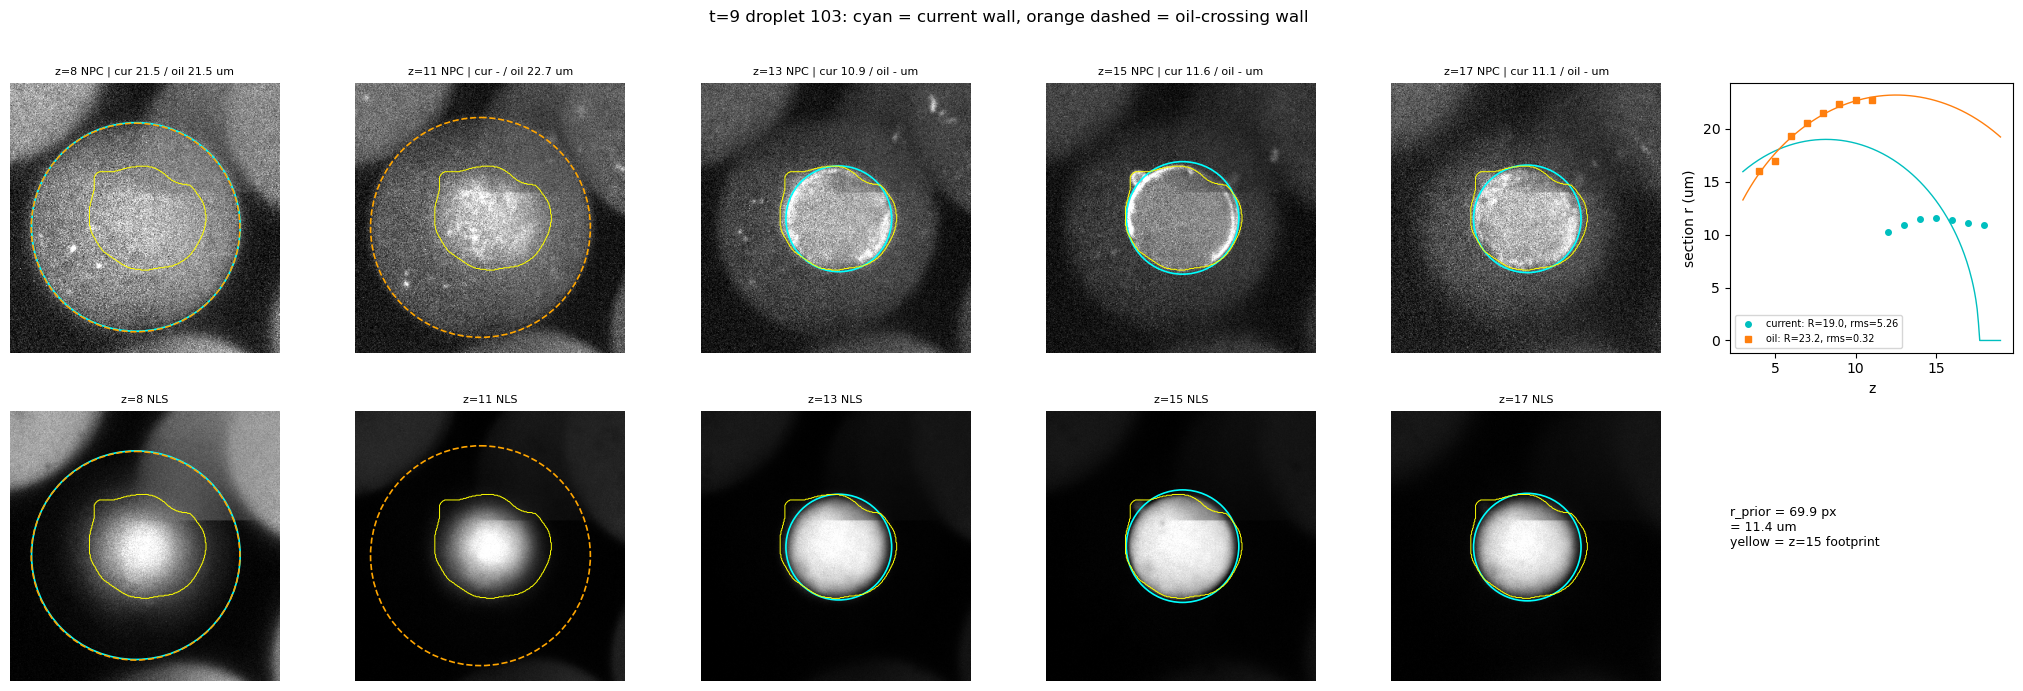

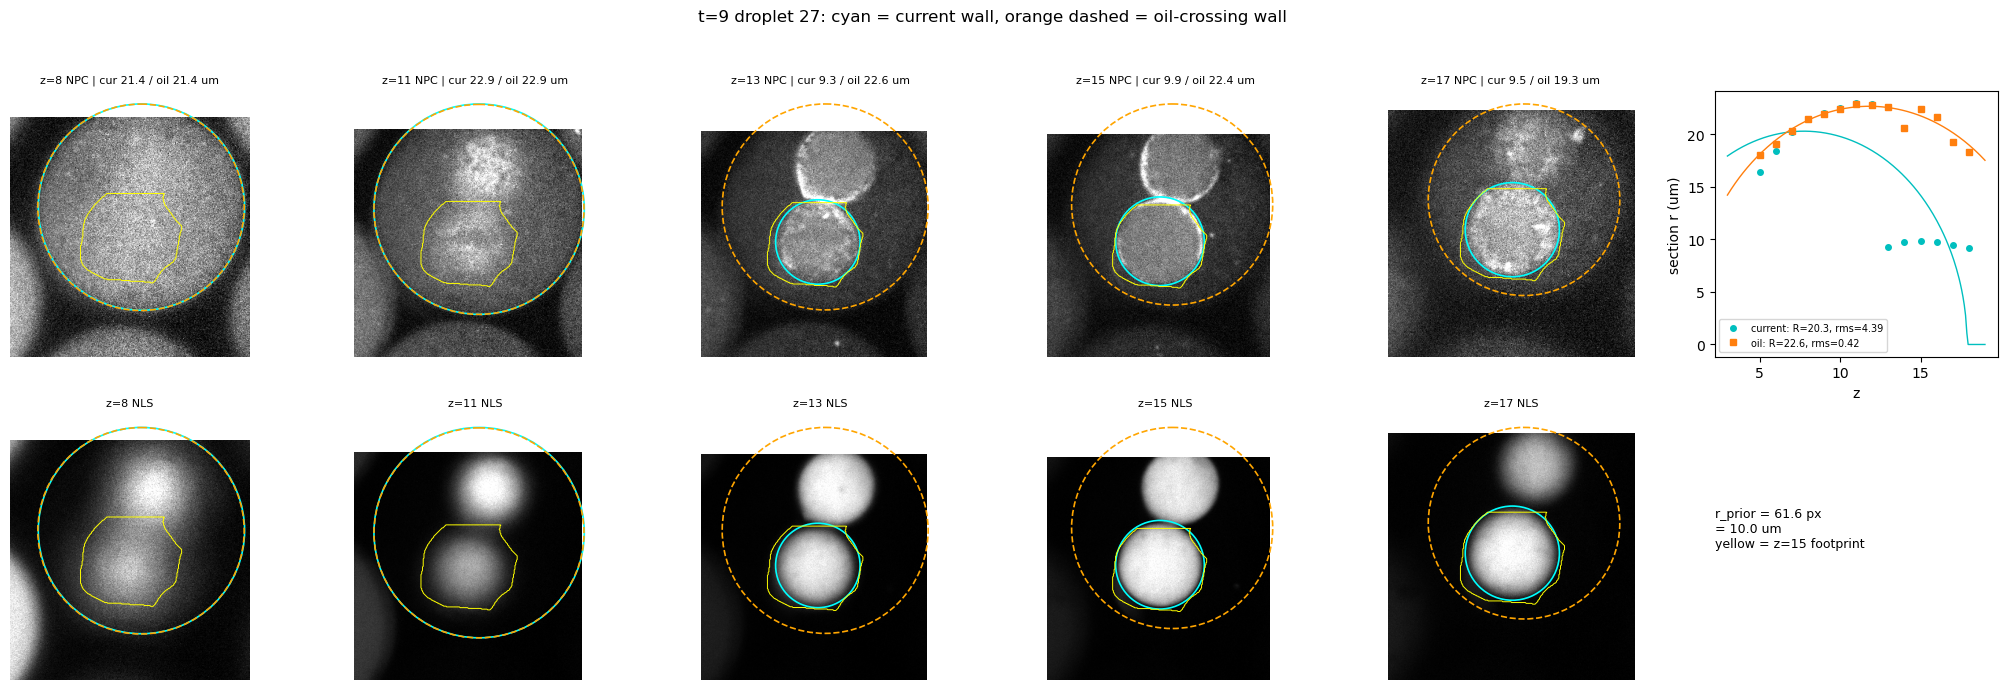

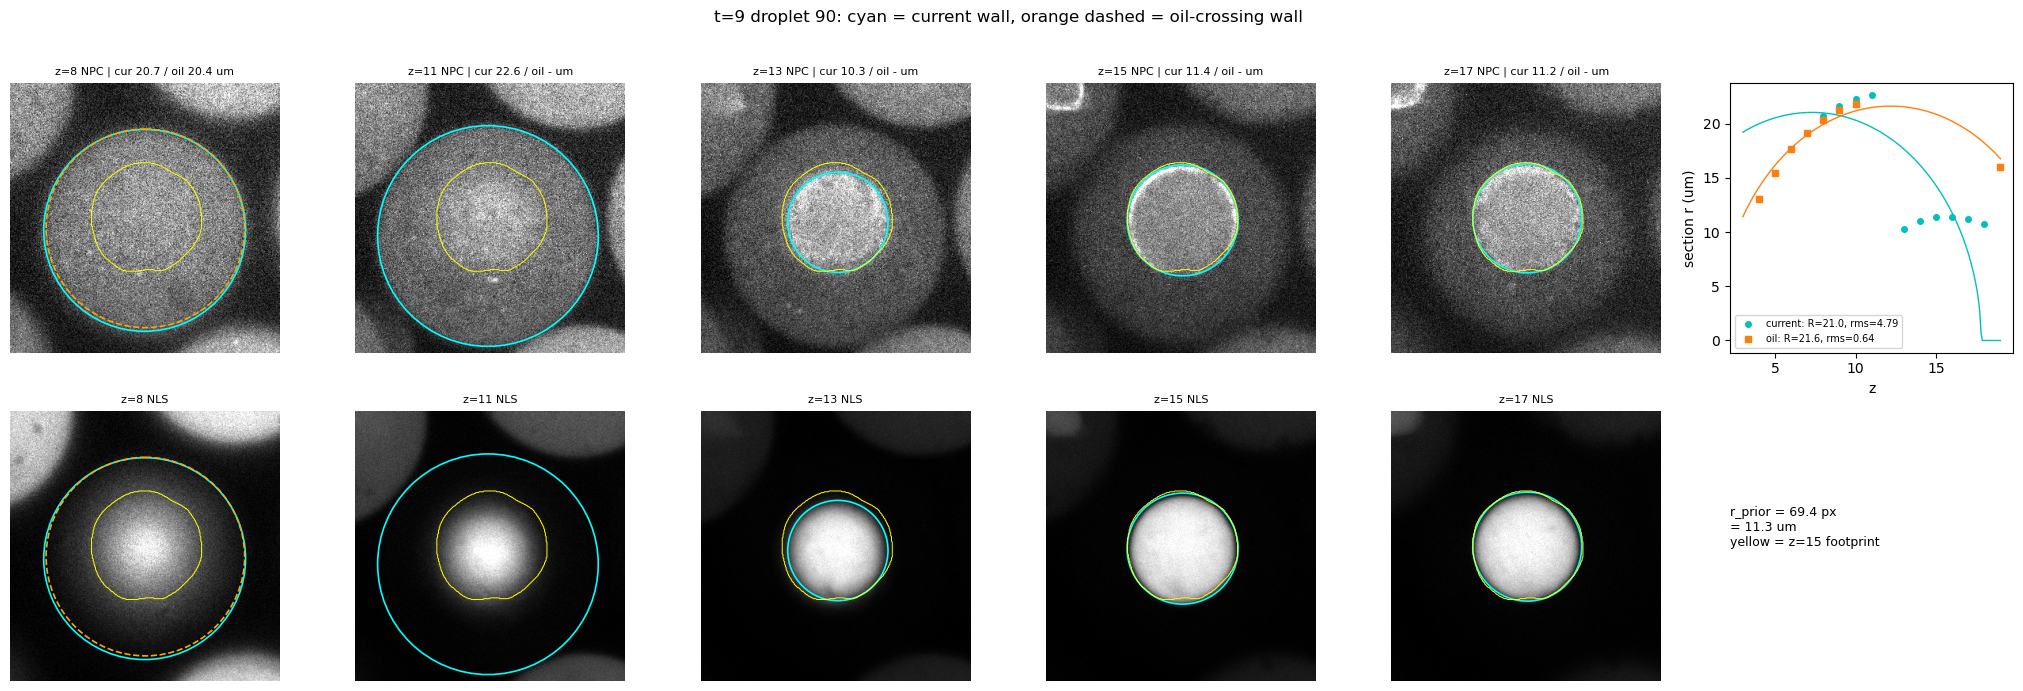

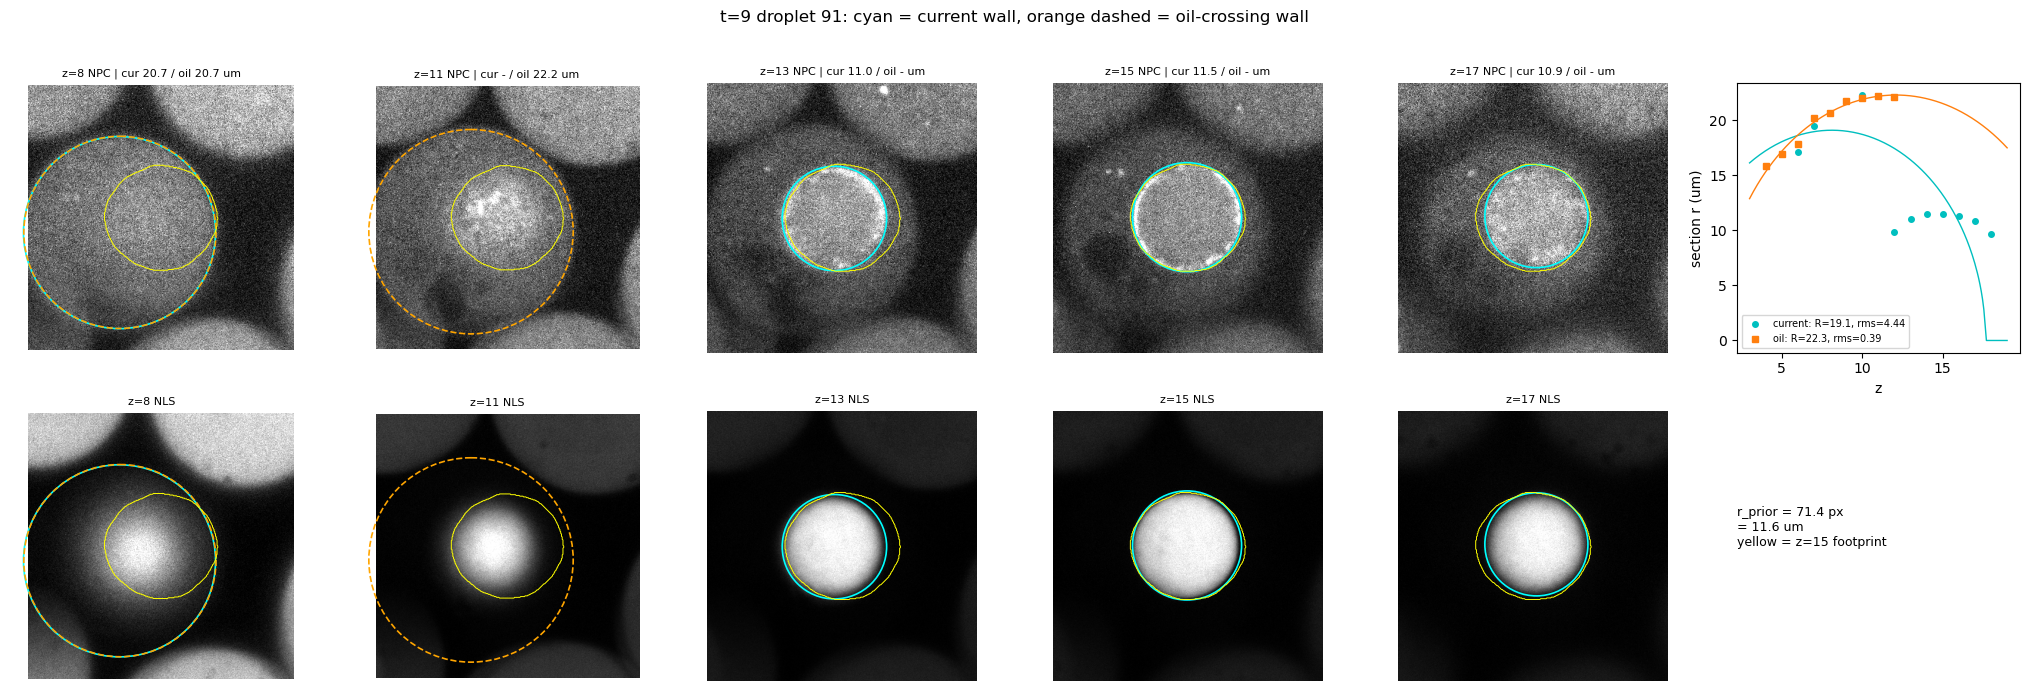

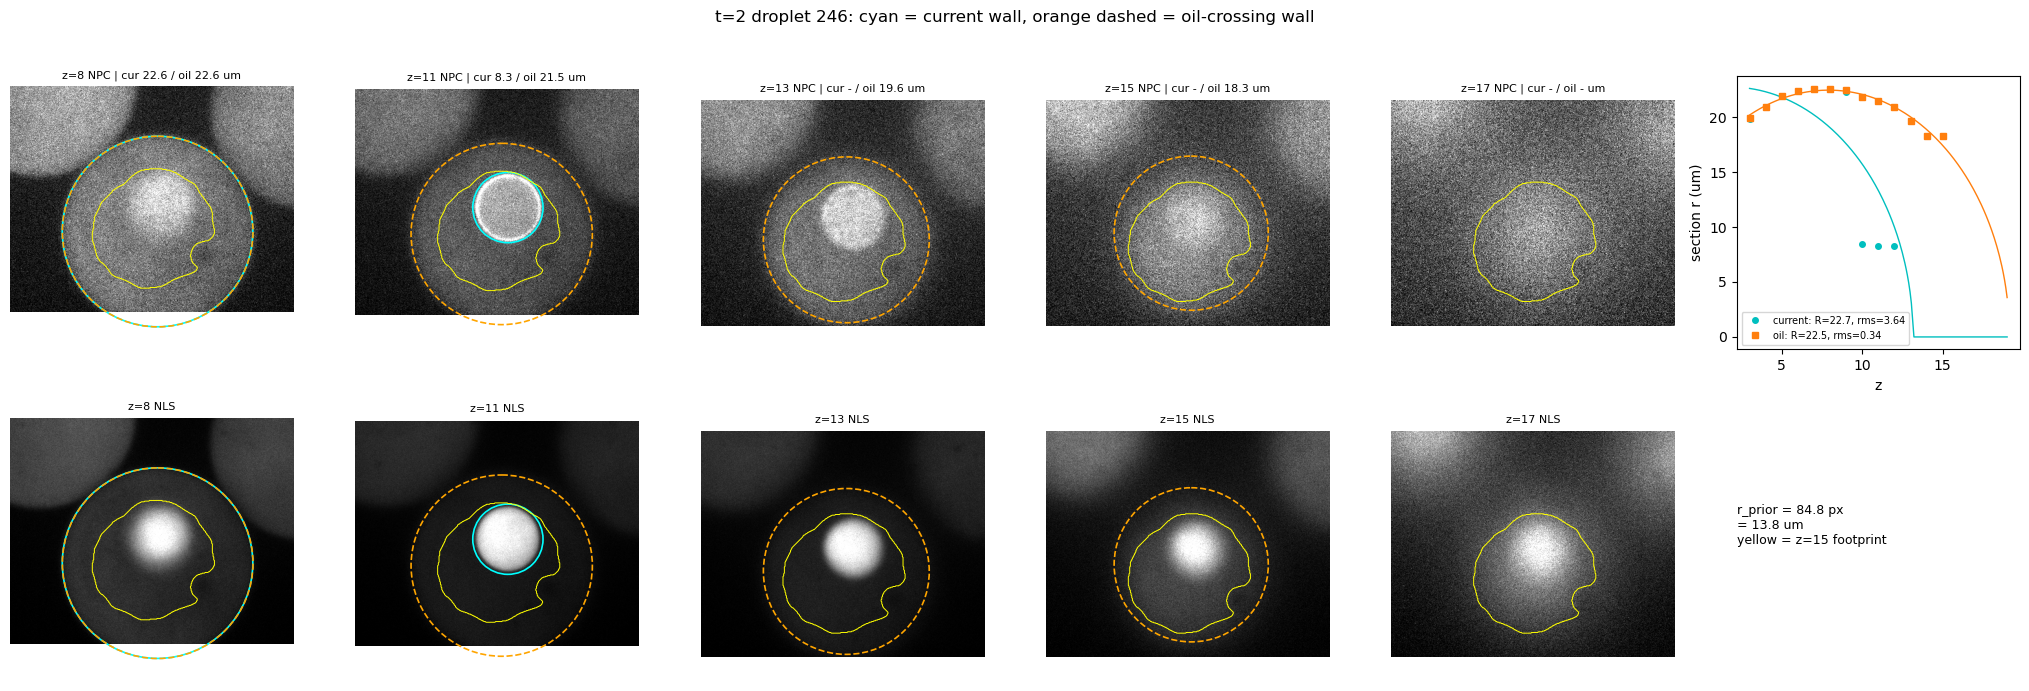

In [14]:
# ONE-OFF, informational (not a fix). Writes nothing; cfg and B3/B4 are unchanged.
#
# Question 1: what are the flat ~10 um circles the t=9 wall fits find at upper
#   planes? Their radius matches each droplet's r_prior (the z=15 inventory
#   footprint), not a droplet section. For each target, panels show raw NPC (top)
#   and NLS (bottom) at DIAG_PLANES with the current B3 circle (cyan), the
#   oil-crossing circle (orange dashed) and the z=15 inventory footprint (yellow).
# Question 2: does defining the wall as "where the ray first enters oil" fix it?
#   Oil-crossing variant: the plane's oil threshold is the LOWEST cut of a
#   three-class Otsu on the smoothed NPC plane (oil / dim cytoplasm / bright
#   droplets and nuclei). A two-class Otsu would call NPC-depleted cytoplasm "oil"
#   whenever other droplets are bright. On each ray, find the first point where the
#   profile drops from above that threshold to below it; the wall is the steepest
#   fall within +/- WALL_CROSS_WINDOW_PX of that crossing. A nuclear envelope falls
#   into cytoplasm, not oil, so it can never be picked; a ray that never reaches
#   oil is skipped. Window, edge guard, strength filter, RANSAC, gates and sphere
#   are B3/B4 unchanged.
# With DIAG_SCALE = True it also refits the whole inventory at DIAG_SCALE_TIMEPOINTS
#   with both variants and prints E1's summary lines side by side (t=2 is the
#   regression check). About 3-4 minutes per timepoint.
from matplotlib.patches import Circle
from IPython.display import display

DIAG_TARGETS = [(9, 103), (9, 27), (9, 90), (9, 91), (2, 246)]   # worst fits in E1
DIAG_PLANES = (8, 11, 13, 15, 17)
WALL_CROSS_WINDOW_PX = 8
DIAG_SCALE = True
DIAG_SCALE_TIMEPOINTS = (2, 9)
R_BAND_FRAC = 0.15          # report droplets whose R is > 15% from the timepoint median


def _oil_threshold(sm):
    """Oil / everything-else cut: lowest threshold of a 3-class Otsu (subsampled)."""
    return float(filters.threshold_multiotsu(sm[::4, ::4], classes=3)[0])


def _wall_points_oil(sm, center_xy, r_prior, thr, cfg=cfg):
    """wall_points_on_smoothed (B3) with the wall placed at the first entry into oil."""
    cx, cy = center_xy
    H, W = sm.shape
    g, k = float(cfg.wall_edge_guard_px), int(WALL_CROSS_WINDOW_PX)
    radii = np.arange(r_prior * cfg.wall_r_lo_frac, r_prior * cfg.wall_r_hi_frac, 1.0)
    pts, strengths = [], []
    for theta in np.linspace(0, 2 * np.pi, cfg.wall_n_rays, endpoint=False):
        dx, dy = np.cos(theta), np.sin(theta)
        xs, ys = cx + radii * dx, cy + radii * dy
        ok = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        n = int(ok.sum())
        if n < 5:
            continue
        prof = ndimage.map_coordinates(sm, [ys[ok], xs[ok]], order=1)
        above = prof > thr
        cross = np.flatnonzero(above[:-1] & ~above[1:])
        if cross.size == 0:
            continue                               # never enters oil: skip the ray
        m = int(cross[0]) + 1
        grad = np.gradient(prof)
        lo, hi = max(0, m - k), min(n, m + k + 1)
        j = lo + int(np.argmin(grad[lo:hi]))
        edge_r = radii[ok][j]
        ex, ey = cx + edge_r * dx, cy + edge_r * dy
        if min(ex, ey, W - 1 - ex, H - 1 - ey) < g:
            continue
        pts.append((ex, ey))
        strengths.append(-grad[j])
    if not pts:
        return np.empty((0, 2))
    pts, strengths = np.array(pts), np.array(strengths)
    return pts[strengths >= np.percentile(strengths, cfg.wall_strength_pct)]


def _gated(wall, seed, r_prior, cfg=cfg):
    """Same RANSAC + gates as fit_droplet_circle_on_smoothed (B3)."""
    if len(wall) < 3:
        return None
    fit = fit_circle_ransac(wall, tol_px=cfg.ransac_tol_px, n_iter=cfg.ransac_n_iter,
                            min_inlier_frac=cfg.ransac_min_inlier_frac)
    if fit is None:
        return None
    cx, cy, r, inl = fit
    if not (cfg.fit_radius_min_frac * r_prior <= r <= cfg.fit_radius_max_frac * r_prior):
        return None
    if np.hypot(cx - seed[0], cy - seed[1]) > cfg.fit_centre_max_frac * r_prior:
        return None
    if float(inl.mean()) < cfg.fit_min_final_inlier_frac:
        return None
    return float(cx), float(cy), float(r)


def _fit_both(hs, t, inv, dids):
    """Per-plane circles for both wall definitions: {'current': [prof], 'oil': [prof]}."""
    zs = list(range(int(cfg.cap_z_floor), hs.shape[1]))
    seeds = {d: (float(inv[d]["centroid"][1]), float(inv[d]["centroid"][0]),
                 float(np.sqrt(inv[d]["area"] / np.pi))) for d in dids}
    out = {"current": {d: {} for d in dids}, "oil": {d: {} for d in dids}}
    for i, z in enumerate(zs):
        print(f"t={t}: z={z} ({i + 1}/{len(zs)})", flush=True)
        sm = smooth_npc_plane(extract_plane(hs, t, z, cfg.npc_channel_idx), cfg)
        thr = _oil_threshold(sm)
        for d, (cx, cy, r) in seeds.items():
            f = fit_droplet_circle_on_smoothed(sm, (cx, cy), r, cfg=cfg)
            if f is not None:
                out["current"][d][z] = f[:3]
            f = _gated(_wall_points_oil(sm, (cx, cy), r, thr), (cx, cy), r)
            if f is not None:
                out["oil"][d][z] = f
        del sm
    return out


def _summary(t, name, profs, n_inv):
    sph = {d: fit_sphere_profile(p, cfg) for d, p in profs.items()}
    ok = {d: s for d, s in sph.items() if s is not None}
    R = np.array([s["R_um"] for s in ok.values()])
    rms = np.array([s["sphere_rms_um"] for s in ok.values()])
    med = np.median(R) if len(R) else np.nan
    caps = sum(any(abs(z - s["z_eq"]) * cfg.z_step_um / s["R_um"] > cfg.cap_u_safe
                   for z in profs[d]) for d, s in ok.items())
    return dict(t=t, wall=name, with_geometry=f"{len(ok)}/{n_inv}",
                R_p5=np.percentile(R, 5).round(2), R_p50=round(med, 2), R_p95=np.percentile(R, 95).round(2),
                R_off_band=int((np.abs(R - med) > R_BAND_FRAC * med).sum()),
                rms_p50=np.percentile(rms, 50).round(3), rms_p95=np.percentile(rms, 95).round(3),
                rms_max=rms.max().round(3), rms_over_1um=int((rms > 1).sum()),
                cap_droplets=caps), sph


def diag_upper_planes():
    hs = load_memmap_tiff(cfg.image_file)
    n_z, H, W = hs.shape[1], hs.shape[-2], hs.shape[-1]
    valid_zs = [z for z in range(n_z) if z_in_focus_range(z, n_z, cfg=cfg)]
    ref_z = cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs else valid_zs[len(valid_zs) // 2]
    tps = sorted(set(DIAG_SCALE_TIMEPOINTS if DIAG_SCALE else ()) | {t for t, _ in DIAG_TARGETS})
    results, rows = {}, []
    for t in tps:
        inv = detect_droplets_npc_watershed(extract_plane(hs, t, ref_z, cfg.npc_channel_idx),
                                            cfg=cfg, compact=True)
        dids = (list(range(len(inv))) if DIAG_SCALE and t in DIAG_SCALE_TIMEPOINTS
                else [d for tt, d in DIAG_TARGETS if tt == t])
        for tt, d in DIAG_TARGETS:
            if tt == t and d >= len(inv):
                raise ValueError(f"t={t}: droplet {d} not in the {len(inv)}-droplet inventory")
        profs = _fit_both(hs, t, inv, dids)
        sph = {}
        for name in ("current", "oil"):
            row, sph[name] = _summary(t, name, profs[name], len(inv))
            if DIAG_SCALE and t in DIAG_SCALE_TIMEPOINTS:
                rows.append(row)
        results[t] = dict(inv=inv, profs=profs, sph=sph)

    if rows:
        print("\nWhole-inventory comparison (same seeds, window, gates and sphere; only the wall definition differs):")
        display(pd.DataFrame(rows))

    zz = np.linspace(cfg.cap_z_floor, n_z - 1, 200)
    for t, d in DIAG_TARGETS:
        res = results[t]
        inv_d = res["inv"][d]
        cy0, cx0 = inv_d["centroid"]
        r_prior = float(np.sqrt(inv_d["area"] / np.pi))
        half = int(np.ceil(cfg.wall_r_hi_frac * r_prior)) + 10
        box = (max(0, int(cy0) - half), max(0, int(cx0) - half),
               min(H, int(cy0) + half + 1), min(W, int(cx0) + half + 1))
        y0, x0 = box[:2]
        foot = _compact_crop((tuple(inv_d["bbox"]), inv_d["mask_local"]), box)
        ncol = len(DIAG_PLANES) + 1
        fig, axes = plt.subplots(2, ncol, figsize=(3.4 * ncol, 7))
        for col, z in enumerate(DIAG_PLANES):
            for row, ch in enumerate((cfg.npc_channel_idx, cfg.nucleus_channel_idx)):
                a = axes[row, col]
                img = read_crop(hs, t, z, ch, box)
                lo, hi = np.percentile(img, [1, 99.5])
                a.imshow(img, cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
                if foot.any():
                    a.contour(foot, levels=[0.5], colors="yellow", linewidths=0.7)
                for name, col_, ls in (("current", "cyan", "-"), ("oil", "orange", "--")):
                    c = res["profs"][name][d].get(z)
                    if c is not None:
                        a.add_patch(Circle((c[0] - x0, c[1] - y0), c[2], fill=False, ec=col_, ls=ls, lw=1.2))
                a.axis("off")
            rc = res["profs"]["current"][d].get(z)
            ro = res["profs"]["oil"][d].get(z)
            fmt = lambda c: "-" if c is None else f"{c[2] * cfg.pixel_size_um:.1f}"
            axes[0, col].set_title(f"z={z} NPC | cur {fmt(rc)} / oil {fmt(ro)} um", fontsize=8)
            axes[1, col].set_title(f"z={z} NLS", fontsize=8)
        a = axes[0, -1]
        for name, col_, mk in (("current", "c", "o"), ("oil", "tab:orange", "s")):
            p, s = res["profs"][name][d], res["sph"][name].get(d)
            if p:
                a.plot(sorted(p), [p[z][2] * cfg.pixel_size_um for z in sorted(p)], mk, color=col_,
                       ms=4, label=f"{name}" + (f": R={s['R_um']:.1f}, rms={s['sphere_rms_um']:.2f}" if s else ": no sphere"))
            if s:
                a.plot(zz, np.sqrt(np.clip(s["R_um"] ** 2 - (cfg.z_step_um * (zz - s["z_eq"])) ** 2, 0, None)),
                       "-", color=col_, lw=1)
        a.set_xlabel("z"); a.set_ylabel("section r (um)"); a.legend(fontsize=7)
        axes[1, -1].axis("off")
        axes[1, -1].text(0, 0.5, f"r_prior = {r_prior:.1f} px\n= {r_prior * cfg.pixel_size_um:.1f} um\n"
                                 "yellow = z=15 footprint", fontsize=9)
        fig.suptitle(f"t={t} droplet {d}: cyan = current wall, orange dashed = oil-crossing wall")
        plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    return results


DIAG_UPPER = diag_upper_planes()

In [ ]:
# ONE-OFF, informational (not a production fix). Writes nothing to disk and does
# not mutate cfg or B3/B4. This is the iterative v2 test motivated by the
# two-pass dump: loose guided candidates are allowed to correct the provisional
# sphere, while final geometry requires four mutually consistent planes.
import copy
import itertools
from matplotlib.patches import Circle
from IPython.display import display

ITER_TIMEPOINTS = (2, 9)
ITER_TARGETS = [(9, 103), (9, 27), (9, 90), (9, 91), (9, 118), (2, 34), (2, 246), (2, 251)]
ITER_PLANES = (5, 8, 11, 13, 15, 17)
ITER_Z_STEP_UM = 2.18       # E1 free-curvature estimate; cfg remains acquisition metadata
ITER_FINAL_MIN_PLANES = 4
ITER_INLIER_TOL_UM = 1.0
ITER_CANDIDATE_TOL_UM = 3.0
ITER_R_LO_FRAC = 0.80       # reject nucleus spheres; deliberately no upper bound
ITER_GUIDED_WINDOW = (0.8, 1.2)
ITER_MIN_PRED_FRAC = 0.30
ITER_MAX_ROUNDS = 5
ITER_CLEAN_RMS_UM = 0.5

iter_cfg = copy.copy(cfg)
iter_cfg.z_step_um = ITER_Z_STEP_UM
iter_cfg.geometry_min_planes = ITER_FINAL_MIN_PLANES
iter_guided_cfg = copy.copy(iter_cfg)
iter_guided_cfg.wall_r_lo_frac, iter_guided_cfg.wall_r_hi_frac = ITER_GUIDED_WINDOW


def _iter_sphere_lsq(z, r, dz):
    B, A = np.polyfit(z, r * r + dz * dz * z * z, 1)
    z_eq = B / (2.0 * dz * dz)
    return float(z_eq), float(A + dz * dz * z_eq * z_eq)


def _iter_robust_sphere(prof, r0_um, min_support=ITER_FINAL_MIN_PLANES):
    """RANSAC sphere with a lower size prior and one observation per z plane."""
    if len(prof) < min_support:
        return None
    zs = np.asarray(sorted(prof), float)
    rr = np.asarray([prof[int(z)][2] for z in zs], float) * iter_cfg.pixel_size_um
    dz = float(iter_cfg.z_step_um)

    def score(z_eq, r2):
        if not np.isfinite(r2) or r2 <= 0 or np.sqrt(r2) < ITER_R_LO_FRAC * r0_um:
            return None
        pred2 = r2 - (dz * (zs - z_eq)) ** 2
        # A zero-clipped prediction must not count as an inlier outside the sphere.
        valid = pred2 > 0
        residual = np.full(len(zs), np.inf)
        residual[valid] = rr[valid] - np.sqrt(pred2[valid])
        inlier = valid & (np.abs(residual) <= ITER_INLIER_TOL_UM)
        return inlier, residual

    best = None
    # Three points may seed round 1 (needed for d103), but a returned final sphere
    # always has min_support inliers. Guided wall candidates then outvote the bad seed.
    for idx in itertools.combinations(range(len(zs)), 3):
        idx = np.asarray(idx)
        try:
            candidate = score(*_iter_sphere_lsq(zs[idx], rr[idx], dz))
        except (ValueError, np.linalg.LinAlgError):
            continue
        if candidate is None:
            continue
        inlier, residual = candidate
        key = (int(inlier.sum()), -float(np.abs(residual[inlier]).sum()))
        if best is None or key > best[0]:
            best = (key, inlier)
    if best is None or best[0][0] < min_support:
        return None

    inlier = best[1]
    for _ in range(3):
        z_eq, r2 = _iter_sphere_lsq(zs[inlier], rr[inlier], dz)
        candidate = score(z_eq, r2)
        if candidate is None or int(candidate[0].sum()) < min_support:
            return None
        new_inlier, residual = candidate
        if np.array_equal(new_inlier, inlier):
            inlier = new_inlier
            break
        inlier = new_inlier
    z_eq, r2 = _iter_sphere_lsq(zs[inlier], rr[inlier], dz)
    candidate = score(z_eq, r2)
    if candidate is None or int(candidate[0].sum()) < min_support:
        return None
    inlier, residual = candidate
    return dict(
        z_eq=float(z_eq), R_um=float(np.sqrt(r2)),
        sphere_rms_um=float(np.sqrt(np.mean(residual[inlier] ** 2))),
        sphere_outliers=[int(z) for z in zs[~inlier]],
        n_planes=int(inlier.sum()),
        z_eq_argmax=int(zs[int(np.argmax(rr))]),
        extrapolated=bool(z_eq < zs[inlier].min() or z_eq > zs[inlier].max()),
        inlier_z=[int(z) for z in zs[inlier]],
    )


def _iter_seed_sphere(prof, r0_um):
    """A three-plane provisional sphere may guide round 1; it is never returned."""
    return _iter_robust_sphere(prof, r0_um, min_support=3)


def _iter_geometry(hs, t, inv):
    zs = list(range(int(cfg.cap_z_floor), hs.shape[1]))
    px = float(iter_cfg.pixel_size_um)
    seeds = [(float(d["centroid"][1]), float(d["centroid"][0]),
              float(np.sqrt(d["area"] / np.pi))) for d in inv]
    # Cache the smoothed planes for this timepoint. This is read-only but large;
    # the caller discards the cache before moving to the next timepoint.
    smoothed = {}
    pass1 = [dict() for _ in inv]
    for i, z in enumerate(zs):
        print(f"t={t} initial plane z={z} ({i + 1}/{len(zs)})", flush=True)
        smoothed[z] = smooth_npc_plane(extract_plane(hs, t, z, cfg.npc_channel_idx), cfg)
        for did, (cx, cy, radius) in enumerate(seeds):
            fit = fit_droplet_circle_on_smoothed(smoothed[z], (cx, cy), radius, cfg=cfg)
            if fit is not None:
                pass1[did][z] = fit[:3]

    old_spheres = [fit_sphere_profile(p, cfg) for p in pass1]
    clean = [s["R_um"] for s in old_spheres
             if s is not None and s["sphere_rms_um"] < ITER_CLEAN_RMS_UM]
    if not clean:
        raise RuntimeError(f"t={t}: no clean initial spheres from which to estimate R prior")
    r0_um = float(np.median(clean))
    print(f"t={t}: R prior {r0_um:.2f} um from {len(clean)} clean initial spheres", flush=True)

    work = [dict(p) for p in pass1]
    source = [{z: 0 for z in p} for p in pass1]  # 0 initial; 1..N guided round
    spheres = [_iter_seed_sphere(p, r0_um) for p in work]
    history = []
    for round_no in range(1, ITER_MAX_ROUNDS + 1):
        attempted = accepted = 0
        previous = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        for did, sphere in enumerate(spheres):
            if sphere is None:
                continue
            g = dict(prof=work[did], **sphere)
            for z in zs:
                if z in sphere["inlier_z"]:
                    continue
                pred = predicted_circle(g, z, iter_cfg)
                if pred is None or pred[2] * px < ITER_MIN_PRED_FRAC * sphere["R_um"]:
                    continue
                attempted += 1
                fit = fit_droplet_circle_on_smoothed(
                    smoothed[z], (pred[0], pred[1]), pred[2], cfg=iter_guided_cfg)
                if fit is not None and abs(fit[2] - pred[2]) * px <= ITER_CANDIDATE_TOL_UM:
                    # A guided fit replaces the same plane's unguided observation;
                    # the next RANSAC round decides whether it belongs to the sphere.
                    work[did][z] = fit[:3]
                    source[did][z] = round_no
                    accepted += 1
        spheres = [_iter_robust_sphere(p, r0_um) for p in work]
        current = [None if s is None else tuple(s["inlier_z"]) for s in spheres]
        changed = sum(a != b for a, b in zip(previous, current))
        history.append(dict(round=round_no, attempted=attempted, accepted=accepted,
                            changed_inlier_sets=changed,
                            final_spheres=sum(s is not None for s in spheres)))
        print(f"t={t} round {round_no}: attempted {attempted}, accepted {accepted}, "
              f"changed {changed}, spheres {history[-1]['final_spheres']}/{len(inv)}", flush=True)
        if changed == 0:
            break
    del smoothed
    return dict(pass1=pass1, old_spheres=old_spheres, prof=work, source=source,
                spheres=spheres, R0=r0_um, history=history)


def _iter_summary(t, name, spheres, profiles, n_inventory, step_um):
    ok = {d: s for d, s in enumerate(spheres) if s is not None}
    if not ok:
        return dict(t=t, method=name, with_geometry=f"0/{n_inventory}")
    radii = np.asarray([s["R_um"] for s in ok.values()])
    rms = np.asarray([s["sphere_rms_um"] for s in ok.values()])
    zeq = np.asarray([s["z_eq"] for s in ok.values()])
    caps = sum(any(abs(z - s["z_eq"]) * step_um / s["R_um"] > cfg.cap_u_safe
                   for z in profiles[d]) for d, s in ok.items())
    return dict(t=t, method=name, with_geometry=f"{len(ok)}/{n_inventory}",
                R_p5=round(float(np.percentile(radii, 5)), 2),
                R_p50=round(float(np.median(radii)), 2),
                R_p95=round(float(np.percentile(radii, 95)), 2),
                rms_p50=round(float(np.percentile(rms, 50)), 3),
                rms_p95=round(float(np.percentile(rms, 95)), 3),
                rms_max=round(float(rms.max()), 3),
                rms_over_1um=int((rms > 1).sum()),
                z_eq_median=round(float(np.median(zeq)), 2),
                planes_mean=round(float(np.mean([s["n_planes"] for s in ok.values()])), 1),
                cap_droplets=int(caps))


def _iter_dump_targets(t, inv, result):
    px = float(iter_cfg.pixel_size_um)
    for tt, did in ITER_TARGETS:
        if tt != t or did >= len(inv):
            continue
        old, new = result["old_spheres"][did], result["spheres"][did]
        fmt = lambda s: "none" if s is None else (f"R={s['R_um']:.2f} z_eq={s['z_eq']:.2f} "
                                                    f"rms={s['sphere_rms_um']:.2f}")
        print(f"\n=== t={t} droplet {did} | old {fmt(old)} | iterative {fmt(new)} ===")
        lines = []
        inliers = set() if new is None else set(new["inlier_z"])
        for z in sorted(set(result["pass1"][did]) | set(result["prof"][did])):
            p0, pn = result["pass1"][did].get(z), result["prof"][did].get(z)
            lines.append(dict(z=z,
                              initial_r_um=None if p0 is None else round(p0[2] * px, 2),
                              iterative_r_um=None if pn is None else round(pn[2] * px, 2),
                              source=("initial" if result["source"][did].get(z, 0) == 0 else
                                      f"round {result['source'][did][z]}"),
                              final=("inlier" if z in inliers else "outlier")))
        print(pd.DataFrame(lines).to_string(index=False))


def diag_iterative_geometry():
    hs = load_memmap_tiff(cfg.image_file)
    valid_zs = [z for z in range(hs.shape[1]) if z_in_focus_range(z, hs.shape[1], cfg=cfg)]
    ref_z = cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs else valid_zs[len(valid_zs) // 2]
    out, summaries = {}, []
    for t in ITER_TIMEPOINTS:
        inv = detect_droplets_npc_watershed(
            extract_plane(hs, t, ref_z, cfg.npc_channel_idx), cfg=cfg, compact=True)
        print(f"t={t}: {len(inv)} droplets in z={ref_z} inventory", flush=True)
        result = _iter_geometry(hs, t, inv)
        summaries.append(_iter_summary(t, "production B4", result["old_spheres"],
                                       result["pass1"], len(inv), float(cfg.z_step_um)))
        summaries.append(_iter_summary(t, "iterative v2", result["spheres"],
                                       result["prof"], len(inv), ITER_Z_STEP_UM))
        _iter_dump_targets(t, inv, result)
        out[t] = dict(inv=inv, **result)
    print("\n=== comparison ===")
    display(pd.DataFrame(summaries))
    return out


DIAG_ITERATIVE = diag_iterative_geometry()


In [ ]:
# FAST follow-up to DIAG_ITERATIVE: no image IO and no disk writes.
# Re-score the already fitted profiles with stricter one-sided radius floors.
# The desired floor rejects t2/d251 (R=17.5 um) without losing the normal
# ~20--23 um population; the coalesced t2/d34 has no upper-radius restriction.
if "DIAG_ITERATIVE" not in globals():
    raise RuntimeError("Run the iterative-v2 diagnostic cell above first.")

_saved_floor = ITER_R_LO_FRAC
_radius_audit_rows = []
try:
    for _floor in (0.75, 0.80, 0.85):
        ITER_R_LO_FRAC = _floor
        for _t, _result in DIAG_ITERATIVE.items():
            _rescored = [_iter_robust_sphere(_p, _result["R0"]) for _p in _result["prof"]]
            _kept = [(_did, _s) for _did, _s in enumerate(_rescored) if _s is not None]
            _radius_audit_rows.append(dict(
                floor=_floor, t=_t,
                with_geometry=f"{len(_kept)}/{len(_result['inv'])}",
                rejected=",".join(str(_did) for _did, _s in enumerate(_rescored) if _s is None) or "-",
                R_min=(round(min(_s["R_um"] for _, _s in _kept), 2) if _kept else np.nan),
                R_p5=(round(float(np.percentile([_s["R_um"] for _, _s in _kept], 5)), 2)
                      if _kept else np.nan),
                d34=("kept" if _t != 2 or _rescored[34] is not None else "REJECTED"),
                d251=("rejected" if _t != 2 or _rescored[251] is None else "KEPT"),
                d118=("rejected" if _t != 9 or _rescored[118] is None else "KEPT"),
            ))
finally:
    ITER_R_LO_FRAC = _saved_floor

RADIUS_FLOOR_AUDIT = pd.DataFrame(_radius_audit_rows)
print(RADIUS_FLOOR_AUDIT.to_string(index=False))


## E3. T2/T3 nucleus segmentation benchmark (read-only)

A deterministic, spatially distributed subset of droplets is sampled at the plane nearest each fitted equator. Local threshold, Otsu, and sharpness-watershed use the same droplet support and physical gates. This cell writes nothing; visual boundary quality is the decision criterion, while area and pairwise IoU expose systematic disagreement.


In [ ]:
# ============================================================
# E3. T2/T3 nucleus segmentation benchmark
# ============================================================
# CHECK, informational (not a fix). Reads the image and writes nothing.
from skimage.morphology import h_maxima, h_minima

E3_TIMEPOINTS = (2, 3)
E3_SAMPLES_PER_T = 6


def _e3_chord_ok(region, droplet_r_px, cfg=cfg):
    tol = 1.0 + float(cfg.chord_tol_frac)
    return (region.feret_diameter_max <= 2.0 * droplet_r_px * tol and
            region.area <= np.pi * (droplet_r_px * tol) ** 2)


def _e3_clean_gate(mask, support, droplet_r_px, cfg=cfg):
    """Shared cleanup/physical gates for all three candidate methods."""
    area = int(support.sum())
    empty = np.zeros_like(support, dtype=bool)
    if area == 0:
        return empty
    mask = morphology.remove_small_objects(mask & support, min_size=64)
    mask = ndimage.binary_fill_holes(mask)
    labels = measure.label(mask)
    kept = np.zeros_like(mask, dtype=bool)
    n = 0
    for region in sorted(measure.regionprops(labels), key=lambda r: -r.area):
        frac = region.area / area
        if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac):
            continue
        if not _e3_chord_ok(region, droplet_r_px, cfg):
            continue
        kept |= labels == region.label
        n += 1
        if n >= int(cfg.nucleus_keep_components):
            break
    return kept


def _e3_local(nls, support, radius, cfg=cfg):
    diameter = 2.0 * np.sqrt(max(int(support.sum()), 1) / np.pi)
    block = max(3, int(diameter / 3.0)) if cfg.nucleus_block_size is None else int(cfg.nucleus_block_size)
    block += block % 2 == 0
    threshold = filters.threshold_local(nls.astype(np.float32), block_size=block)
    return _e3_clean_gate(nls > threshold, support, radius, cfg)


def _e3_otsu(nls, support, radius, cfg=cfg):
    values = nls[support]
    if values.size == 0 or values.max() <= values.min():
        return np.zeros_like(support, bool)
    return _e3_clean_gate(nls > filters.threshold_otsu(values), support, radius, cfg)


def _e3_normalize(nls, support):
    values = nls[support]
    if values.size < 10:
        return np.zeros_like(nls, np.float32)
    lo, hi = np.percentile(values, [1, 99.5])
    out = np.clip((nls.astype(np.float32) - lo) / max(hi - lo, 1e-6), 0, 1)
    out[~support] = 0
    return out


def _e3_sharpness(image, cfg=cfg):
    grad = filters.sobel(image)
    win = int(cfg.sharpness_window_px)
    spread = ndimage.maximum_filter(image, win) - ndimage.minimum_filter(image, win)
    return grad / (spread + 1e-3 * (image.max() - image.min() + 1e-9))


def _e3_watershed(nls, support, radius, cfg=cfg):
    empty = np.zeros_like(support, bool)
    normalized = _e3_normalize(nls, support) if cfg.nucleus_norm_within_droplet else nls.astype(np.float32)
    smooth = filters.gaussian(normalized, cfg.ws_smooth_sigma, preserve_range=True)
    interior = morphology.binary_erosion(support, morphology.disk(cfg.ws_wall_band_px))
    rim = support & ~interior
    extrema = (h_maxima(smooth, cfg.ws_h_marker) | h_minima(smooth, cfg.ws_h_marker)) & interior
    markers = measure.label(extrema)
    if markers.max() == 0:
        return empty
    rim_label = int(markers.max()) + 1
    markers[rim] = rim_label
    labels = watershed(_e3_sharpness(smooth, cfg), markers, mask=support)
    labels[rim] = 0
    labels[labels == rim_label] = 0
    candidate = np.zeros_like(support, bool)
    accepted = []
    support_area = int(support.sum())
    for region in measure.regionprops(labels, intensity_image=smooth):
        frac = region.area / support_area
        if not (cfg.nucleus_min_frac <= frac <= cfg.nucleus_max_frac):
            continue
        if not _e3_chord_ok(region, radius, cfg):
            continue
        rest = smooth[interior & (labels != region.label)]
        if rest.size < 50:
            continue
        if abs(region.mean_intensity - float(rest.mean())) < cfg.ws_min_contrast_std * float(rest.std() + 1e-6):
            continue
        accepted.append(region)
    for region in sorted(accepted, key=lambda r: -r.area)[:int(cfg.nucleus_keep_components)]:
        candidate |= labels == region.label
    return _e3_clean_gate(candidate, support, radius, cfg)


def _e3_iou(a, b):
    union = int((a | b).sum())
    return float((a & b).sum() / union) if union else (1.0 if not a.any() and not b.any() else 0.0)


def _e3_sample_ids(inv, geometry, n):
    """Deterministic field-spanning selection; no outcome-based cherry-picking."""
    valid = sorted(geometry, key=lambda did: (inv[did]["centroid"][0], inv[did]["centroid"][1]))
    if len(valid) <= n:
        return valid
    indices = np.linspace(0, len(valid) - 1, n).round().astype(int)
    return [valid[i] for i in indices]


def segmentation_benchmark(cfg=cfg):
    hs = load_memmap_tiff(cfg.image_file)
    valid_zs = [z for z in range(hs.shape[1]) if z_in_focus_range(z, hs.shape[1], cfg=cfg)]
    ref_z = cfg.inventory_ref_z if cfg.inventory_ref_z in valid_zs else valid_zs[len(valid_zs) // 2]
    rows, selected = [], {}
    for t in E3_TIMEPOINTS:
        inv = detect_droplets_npc_watershed(
            extract_plane(hs, t, ref_z, cfg.npc_channel_idx), cfg=cfg, compact=True)
        # Reuse E1's t2 geometry when it exists; inventory detection is deterministic.
        if t in globals().get("E1_RESULTS", {}):
            geometry = E1_RESULTS[t][1]
            print(f"t={t}: reusing E1 geometry", flush=True)
        else:
            print(f"t={t}: computing read-only geometry for segmentation subset", flush=True)
            geometry = compute_droplet_geometry(hs, t, inv, cfg=cfg)
        ids = _e3_sample_ids(inv, geometry, E3_SAMPLES_PER_T)
        selected[t] = ids
        samples = []
        for did in ids:
            g = geometry[did]
            z = int(np.clip(round(g["z_eq"]), 0, hs.shape[1] - 1))
            circle = (g["prof"].get(z) if z in g["prof"] and z not in g["sphere_outliers"]
                      else predicted_circle(g, z, cfg))
            if circle is None:
                continue
            cx, cy, radius = circle
            half = int(np.ceil(radius)) + 12
            y0, x0 = max(0, int(cy) - half), max(0, int(cx) - half)
            y1, x1 = min(hs.shape[-2], int(cy) + half + 1), min(hs.shape[-1], int(cx) + half + 1)
            image = read_crop(hs, t, z, cfg.nucleus_channel_idx, (y0, x0, y1, x1))
            yy, xx = np.ogrid[:image.shape[0], :image.shape[1]]
            support_r = max(float(radius) - float(cfg.erosion_px), 1.0)
            support = (xx - (cx - x0)) ** 2 + (yy - (cy - y0)) ** 2 <= support_r ** 2
            masks = {
                "Local": _e3_local(image, support, support_r, cfg),
                "Otsu": _e3_otsu(image, support, support_r, cfg),
                "Watershed": _e3_watershed(image, support, support_r, cfg),
            }
            area = max(int(support.sum()), 1)
            rows.append(dict(
                t=t, droplet=did, z=z,
                local_frac=masks["Local"].sum() / area,
                otsu_frac=masks["Otsu"].sum() / area,
                watershed_frac=masks["Watershed"].sum() / area,
                iou_local_otsu=_e3_iou(masks["Local"], masks["Otsu"]),
                iou_local_watershed=_e3_iou(masks["Local"], masks["Watershed"]),
                iou_otsu_watershed=_e3_iou(masks["Otsu"], masks["Watershed"])))
            samples.append((did, z, image, support, masks))

        fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3.1 * len(samples)), squeeze=False)
        for row, (did, z, image, support, masks) in enumerate(samples):
            lo, hi = np.percentile(image[support], [1, 99.5])
            for col, title in enumerate(("Raw NLS", "Local", "Otsu", "Watershed")):
                ax = axes[row, col]
                ax.imshow(image, cmap="gray", vmin=lo, vmax=max(hi, lo + 1))
                ax.contour(support, levels=[0.5], colors="yellow", linewidths=0.6)
                if title != "Raw NLS" and masks[title].any():
                    ax.contour(masks[title], levels=[0.5], colors="cyan", linewidths=1.2)
                    frac = masks[title].sum() / max(support.sum(), 1)
                    ax.set_title(f"{title}: {frac:.3f} of droplet")
                else:
                    ax.set_title(title if title == "Raw NLS" else f"{title}: empty")
                ax.axis("off")
            axes[row, 0].set_ylabel(f"d{did}, z={z}", fontsize=10)
        fig.suptitle(f"T{t} nucleus segmentation: yellow=droplet support, cyan=segmentation")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    result = pd.DataFrame(rows)
    print("selected droplet IDs:", selected)
    print(result.round(3).to_string(index=False))
    print("\nmedian by timepoint:")
    print(result.groupby("t").median(numeric_only=True).round(3).to_string())
    return result


if RUN_SEGMENTATION_BENCHMARK:
    E3_SEGMENTATION_RESULT = segmentation_benchmark()


In [ ]:
# E3b. Same droplets across adjacent z planes (read-only).
# Run after the E3 definitions. Uses the T2/T9 IDs from the inspected comparison.
E3_Z_IDS = {2: [0, 50, 100, 150, 200, 249], 9: [0, 35, 68, 106, 144, 179]}
E3_Z_OFFSETS = (-2, -1, 0, 1, 2)

def segmentation_z_benchmark(cfg=cfg):
    hs = load_memmap_tiff(cfg.image_file)
    rows = []
    for t, ids in E3_Z_IDS.items():
        if t not in globals().get("E1_RESULTS", {}):
            raise RuntimeError(f"E1_RESULTS[{t}] missing: run E1 for this timepoint first.")
        geometry = E1_RESULTS[t][1]
        for did in ids:
            if did not in geometry:
                print(f"Skipping t={t}, d={did}: no accepted geometry")
                continue
            g = geometry[did]
            z0 = int(round(g["z_eq"]))
            samples = []
            for offset in E3_Z_OFFSETS:
                z = z0 + offset
                if not 0 <= z < hs.shape[1]:
                    continue
                fitted = z in g["prof"] and z not in g["sphere_outliers"]
                circle = g["prof"][z] if fitted else predicted_circle(g, z, cfg)
                if circle is not None:
                    samples.append((z, offset, circle, fitted))
            if not samples:
                continue
            # Fixed field of view and pooled display limits across all z planes.
            x0 = max(0, int(np.floor(min(c[0]-c[2] for _, _, c, _ in samples))) - 12)
            y0 = max(0, int(np.floor(min(c[1]-c[2] for _, _, c, _ in samples))) - 12)
            x1 = min(hs.shape[-1], int(np.ceil(max(c[0]+c[2] for _, _, c, _ in samples))) + 13)
            y1 = min(hs.shape[-2], int(np.ceil(max(c[1]+c[2] for _, _, c, _ in samples))) + 13)
            prepared = []
            for z, offset, (cx, cy, radius), fitted in samples:
                image = read_crop(hs, t, z, cfg.nucleus_channel_idx, (y0, x0, y1, x1))
                yy, xx = np.ogrid[:image.shape[0], :image.shape[1]]
                radius = max(radius - cfg.erosion_px, 1.0)
                support = (xx-(cx-x0))**2 + (yy-(cy-y0))**2 <= radius**2
                if not support.any():
                    continue
                masks = {"Local": _e3_local(image, support, radius, cfg),
                         "Otsu": _e3_otsu(image, support, radius, cfg),
                         "Watershed": _e3_watershed(image, support, radius, cfg)}
                prepared.append((z, offset, image, support, masks, fitted))
                for method, mask in masks.items():
                    rows.append(dict(t=t, droplet=did, z=z, offset=offset, method=method,
                                     support_source="fitted" if fitted else "predicted",
                                     area_um2=float(mask.sum()*cfg.pixel_size_um**2),
                                     area_fraction=float(mask.sum()/support.sum()),
                                     empty=not bool(mask.any())))
            if not prepared:
                continue
            lo, hi = np.percentile(np.concatenate([im[sup] for _, _, im, sup, _, _ in prepared]), [1, 99.5])
            fig, axes = plt.subplots(len(prepared), 4, figsize=(14, 3*len(prepared)), squeeze=False)
            for row, (z, offset, image, support, masks, fitted) in enumerate(prepared):
                for col, method in enumerate(("Raw NLS", "Local", "Otsu", "Watershed")):
                    ax = axes[row, col]
                    ax.imshow(image, cmap="gray", vmin=lo, vmax=max(hi, lo+1))
                    ax.contour(support, levels=[0.5], colors="yellow", linewidths=0.6,
                               linestyles="solid" if fitted else "dashed")
                    title = f"z={z} ({offset:+d}) | {method}"
                    if method != "Raw NLS":
                        mask = masks[method]
                        if mask.any():
                            ax.contour(mask, levels=[0.5], colors="cyan", linewidths=1.1)
                        title += f" | {mask.sum()/support.sum():.3f}"
                    ax.set_title(title, fontsize=9)
                    ax.axis("off")
            fig.suptitle(f"T{t}, droplet {did}: droplet equator z={g['z_eq']:.2f}\n"
                         "Cyan: segmentation; yellow: support (dashed = sphere-predicted)")
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()
            plt.close(fig)
    result = pd.DataFrame(rows)
    if not result.empty:
        print(result.round(3).to_string(index=False))
    return result

E3_Z_RESULT = segmentation_z_benchmark()


In [ ]:
# E3c. Otsu enrichment/solidity preview. Read-only; trial cutoffs, not validated defaults.
# Run after E3 definitions and E1. Same T2/T9 droplets as the preceding visual comparison.
E3_FILTER_IDS = {2: [0, 50, 100, 150, 200, 249], 9: [0, 35, 68, 106, 144, 179]}
E3_FILTER_OFFSETS = (-2, -1, 0, 1, 2)
E3_MIN_ENRICHMENT = 1.20
E3_MIN_SOLIDITY = 0.80
E3_RING_GAP_UM = 0.5
E3_RING_WIDTH_UM = 2.0
E3_MIN_RING_PIXELS = 50
# Raw NLS means are used; camera offset affects ratios. No background subtraction is assumed.
# Missing/invalid cytoplasm measurements are marked unassessable, not accepted.

def _e3_filter_candidates(image, support, radius, cfg=cfg):
    baseline = _e3_otsu(image, support, radius, cfg) & support
    labels = measure.label(baseline)
    values = image[support]
    # Exclude ALL Otsu foreground from the cytoplasm ring, including components
    # discarded by the existing size gates (they can still contaminate the reference).
    foreground = (image > filters.threshold_otsu(values)) & support if values.size and values.max() > values.min() else baseline
    gap = max(1, int(np.ceil(E3_RING_GAP_UM / cfg.pixel_size_um)))
    outer = gap + max(1, int(np.ceil(E3_RING_WIDTH_UM / cfg.pixel_size_um)))
    kept = np.zeros_like(support, bool)
    records = []
    for region in measure.regionprops(labels):
        candidate = labels == region.label
        ring = (morphology.binary_dilation(candidate, morphology.disk(outer)) &
                ~morphology.binary_dilation(candidate, morphology.disk(gap)) &
                support & ~foreground)
        n_ring = int(ring.sum())
        inside = float(np.mean(image[candidate], dtype=np.float64))
        outside = float(np.mean(image[ring], dtype=np.float64)) if n_ring else np.nan
        valid = n_ring >= E3_MIN_RING_PIXELS and np.isfinite(outside) and outside > 0 and np.isfinite(inside)
        enrichment = inside / outside if valid else np.nan
        solidity = float(region.solidity)
        reasons = []
        if not valid:
            reasons.append('unassessable cytoplasm')
        elif enrichment < E3_MIN_ENRICHMENT:
            reasons.append('enrichment')
        if not np.isfinite(solidity) or solidity < E3_MIN_SOLIDITY:
            reasons.append('solidity')
        accepted = not reasons
        if accepted:
            kept |= candidate
        records.append(dict(candidate=int(region.label), enrichment=enrichment, solidity=solidity,
                            nucleus_mean=inside, cytoplasm_mean=outside, ring_pixels=n_ring,
                            candidate_area_um2=float(region.area * cfg.pixel_size_um**2),
                            accepted=accepted, reason='keep' if accepted else ' + '.join(reasons),
                            centroid=region.centroid))
    return baseline, kept, labels, records

def segmentation_filter_benchmark(cfg=cfg):
    hs = load_memmap_tiff(cfg.image_file)
    rows = []
    for t, ids in E3_FILTER_IDS.items():
        if t not in globals().get("E1_RESULTS", {}):
            raise RuntimeError(f"E1_RESULTS[{t}] missing: run E1 for this timepoint first.")
        geometry = E1_RESULTS[t][1]
        for did in ids:
            if did not in geometry:
                print(f"Skipping t={t}, d={did}: no accepted geometry")
                continue
            g = geometry[did]
            z0 = int(round(g["z_eq"]))
            samples = []
            for offset in E3_FILTER_OFFSETS:
                z = z0 + offset
                if not 0 <= z < hs.shape[1]:
                    continue
                fitted = z in g["prof"] and z not in g["sphere_outliers"]
                circle = g["prof"][z] if fitted else predicted_circle(g, z, cfg)
                if circle is not None:
                    samples.append((z, offset, circle, fitted))
            if not samples:
                continue
            # Fixed field of view and pooled display limits across all z planes.
            x0 = max(0, int(np.floor(min(c[0]-c[2] for _, _, c, _ in samples))) - 12)
            y0 = max(0, int(np.floor(min(c[1]-c[2] for _, _, c, _ in samples))) - 12)
            x1 = min(hs.shape[-1], int(np.ceil(max(c[0]+c[2] for _, _, c, _ in samples))) + 13)
            y1 = min(hs.shape[-2], int(np.ceil(max(c[1]+c[2] for _, _, c, _ in samples))) + 13)
            prepared = []
            for z, offset, (cx, cy, radius), fitted in samples:
                image = read_crop(hs, t, z, cfg.nucleus_channel_idx, (y0, x0, y1, x1))
                yy, xx = np.ogrid[:image.shape[0], :image.shape[1]]
                radius = max(radius - cfg.erosion_px, 1.0)
                support = (xx-(cx-x0))**2 + (yy-(cy-y0))**2 <= radius**2
                if not support.any():
                    continue
                baseline, kept, labels, records = _e3_filter_candidates(image, support, radius, cfg)
                masks = {"Otsu": baseline, "Filtered": kept}
                prepared.append((z, offset, image, support, masks, fitted, labels, records))
                if not records:
                    rows.append(dict(t=t, droplet=did, z=z, offset=offset,
                                     reason="no baseline candidate", candidate=0, accepted=False))
                for record in records:
                    rows.append(dict(t=t, droplet=did, z=z, offset=offset,
                                     support_source="fitted" if fitted else "predicted",
                                     **{k: v for k, v in record.items() if k != "centroid"}))
            if not prepared:
                continue
            lo, hi = np.percentile(np.concatenate([item[2][item[3]] for item in prepared]), [1, 99.5])
            fig, axes = plt.subplots(len(prepared), 4, figsize=(17, 3.2*len(prepared)), squeeze=False)
            for row, (z, offset, image, support, masks, fitted, labels, records) in enumerate(prepared):
                for col, title in enumerate(("Raw NLS", "Otsu", "Filtered")):
                    ax = axes[row, col]
                    ax.imshow(image, cmap="gray", vmin=lo, vmax=max(hi, lo+1))
                    ax.contour(support, levels=[0.5], colors="yellow", linewidths=0.6,
                               linestyles="solid" if fitted else "dashed")
                    if title == "Otsu":
                        for record in records:
                            candidate = labels == record["candidate"]
                            color = "cyan" if record["accepted"] else "red"
                            ax.contour(candidate, levels=[0.5], colors=color, linewidths=1.1)
                            cy, cx = record["centroid"]
                            ax.text(cx, cy, str(record["candidate"]), color=color, fontsize=9)
                    elif title == "Filtered" and masks[title].any():
                        ax.contour(masks[title], levels=[0.5], colors="cyan", linewidths=1.1)
                    ax.set_title(f"z={z} ({offset:+d}) | {title}", fontsize=10)
                    ax.axis("off")
                axes[row, 3].axis("off")
                lines = [f"c{r['candidate']}: E={r['enrichment']:.2f}, S={r['solidity']:.2f}\n"
                         f"  {r['reason']}; ring n={r['ring_pixels']}" for r in records]
                axes[row, 3].text(0, 0.95, "\n\n".join(lines) or "No baseline Otsu candidate",
                                  transform=axes[row, 3].transAxes, va="top", fontsize=10)
            fig.suptitle(f"T{t}, droplet {did}: trial E >= {E3_MIN_ENRICHMENT}, S >= {E3_MIN_SOLIDITY}\n"
                         "Cyan: kept; red: rejected/unassessable; yellow: support (dashed = predicted)")
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()
            plt.close(fig)
    result = pd.DataFrame(rows)
    if not result.empty:
        print(result.round(3).to_string(index=False))
    return result

# Re-run this cell after adjusting the trial cutoffs above.
E3_FILTER_RESULT = segmentation_filter_benchmark()
